# Deep EDA — Data Klaim Asuransi

Notebook ini berisi analisis mendalam terhadap data klaim asuransi untuk menggali insight bisnis yang actionable.

**Dataset:**
- `Data_Klaim.csv` — 4,627 records klaim
- `Data_Polis.csv` — 4,096 records polis (di-join untuk analisis demografis)

---
## Phase 0: Setup, Data Cleansing & Feature Engineering

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.facecolor'] = 'white'

In [3]:
# Load data
dk = pd.read_csv('dataset/Data_Klaim.csv',
                 parse_dates=['Tanggal Pembayaran Klaim', 'Tanggal Pasien Masuk RS', 'Tanggal Pasien Keluar RS'])
dp = pd.read_csv('dataset/Data_Polis.csv')
dk = dk.copy("deep")
dp = dp.copy("deep")
print(f'Data Klaim : {dk.shape[0]:,} rows x {dk.shape[1]} cols')
print(f'Data Polis : {dp.shape[0]:,} rows x {dp.shape[1]} cols')
print(f'\nMissing values (Klaim):')
print(dk.isnull().sum()[dk.isnull().sum() > 0])

Data Klaim : 4,627 rows x 13 cols
Data Polis : 4,096 rows x 6 cols

Missing values (Klaim):
Inpatient/Outpatient        37
ICD Diagnosis                6
ICD Description              6
Tanggal Pembayaran Klaim    37
Lokasi RS                    7
dtype: int64


### 0.1 Data Cleansing
- Drop kolom `Status Klaim` (100% PAID, tidak informatif)
- Drop 2 row yang kehilangan IP/OP, ICD, dan Tgl Bayar sekaligus (data sangat tidak lengkap)
- Sisanya tetap dipertahankan (missing hanya di 1 kolom, masih bisa dianalisis)

In [4]:
# Drop kolom Status Klaim (100% PAID)
dk = dk.drop(columns=['Status Klaim'])

# Drop 2 row yang kosong di banyak kolom sekaligus (C-0362-M, C-0363-M)
worst_rows = dk[
    dk['Inpatient/Outpatient'].isnull() &
    dk['ICD Diagnosis'].isnull() &
    dk['Tanggal Pembayaran Klaim'].isnull()
].index
print(f'Menghapus {len(worst_rows)} row dengan missing values terlalu banyak:')
print(dk.loc[worst_rows, ['Claim ID', 'Nomor Polis']].to_string(index=False))
dk = dk.drop(index=worst_rows).reset_index(drop=True)

print(f'\nSisa missing values:')
print(dk.isnull().sum()[dk.isnull().sum() > 0])
print(f'\nShape setelah cleansing: {dk.shape}')

Menghapus 2 row dengan missing values terlalu banyak:
Claim ID Nomor Polis
C-0362-M    POL-0317
C-0363-M    POL-0317

Sisa missing values:
Inpatient/Outpatient        35
ICD Diagnosis                4
ICD Description              4
Tanggal Pembayaran Klaim    35
Lokasi RS                    7
dtype: int64

Shape setelah cleansing: (4625, 12)


### 0.2 Join Data Klaim + Data Polis

In [5]:
# Parse tanggal lahir dari format YYYYMMDD
dp['Tanggal Lahir'] = pd.to_datetime(dp['Tanggal Lahir'].astype(str), format='%Y%m%d', errors='coerce')
dp['Tanggal Efektif Polis'] = pd.to_datetime(dp['Tanggal Efektif Polis'].astype(str), format='%Y%m%d', errors='coerce')

# Left join
df = dk.merge(dp, on='Nomor Polis', how='left')
print(f'Shape setelah join: {df.shape}')
print(f'Kolom baru: {[c for c in df.columns if c not in dk.columns]}')

Shape setelah join: (4625, 17)
Kolom baru: ['Plan Code', 'Gender', 'Tanggal Lahir', 'Tanggal Efektif Polis', 'Domisili']


### 0.3 Feature Engineering

In [6]:
# Usia saat masuk RS
df['Usia'] = ((df['Tanggal Pasien Masuk RS'] - df['Tanggal Lahir']).dt.days / 365.25).astype(int)

# Length of Stay (hari)
df['LOS'] = (df['Tanggal Pasien Keluar RS'] - df['Tanggal Pasien Masuk RS']).dt.days

# Claim Processing Days (lead time bayar)
df['Processing_Days'] = (df['Tanggal Pembayaran Klaim'] - df['Tanggal Pasien Keluar RS']).dt.days

# Selisih & Rasio Coverage
df['Selisih_Klaim'] = df['Nominal Klaim Yang Disetujui'] - df['Nominal Biaya RS Yang Terjadi']
df['Rasio_Coverage'] = df['Nominal Klaim Yang Disetujui'] / df['Nominal Biaya RS Yang Terjadi'].replace(0, np.nan)

# Temporal features
df['Bulan'] = df['Tanggal Pasien Masuk RS'].dt.to_period('M').astype(str)
df['Kuartal'] = df['Tanggal Pasien Masuk RS'].dt.to_period('Q').astype(str)
df['DayOfWeek'] = df['Tanggal Pasien Masuk RS'].dt.day_name()

# Kategori Nominal
bins = [0, 5e6, 25e6, 100e6, np.inf]
labels = ['< 5 Juta', '5-25 Juta', '25-100 Juta', '> 100 Juta']
df['Kategori_Nominal'] = pd.cut(df['Nominal Klaim Yang Disetujui'], bins=bins, labels=labels, include_lowest=True)

# ICD Group (huruf pertama kode ICD)
icd_map = {
    'A': 'Infeksi', 'B': 'Infeksi',
    'C': 'Neoplasma/Kanker', 'D': 'Neoplasma/Darah',
    'E': 'Endokrin/Metabolik',
    'F': 'Mental/Perilaku',
    'G': 'Saraf',
    'H': 'Mata/Telinga',
    'I': 'Kardiovaskular',
    'J': 'Respiratori',
    'K': 'Pencernaan',
    'L': 'Kulit',
    'M': 'Muskuloskeletal',
    'N': 'Genitourinari',
    'O': 'Kehamilan',
    'Q': 'Kongenital',
    'R': 'Gejala Umum',
    'S': 'Cedera', 'T': 'Cedera',
    'Z': 'Faktor Kesehatan'
}
df['ICD_Letter'] = df['ICD Diagnosis'].str[0]
df['ICD_Group'] = df['ICD_Letter'].map(icd_map).fillna('Lainnya')

print('Feature engineering selesai!')
print(f'Kolom baru: Usia, LOS, Processing_Days, Selisih_Klaim, Rasio_Coverage,')
print(f'            Bulan, Kuartal, DayOfWeek, Kategori_Nominal, ICD_Group')
print(f'\nSample data:')
df[['Claim ID', 'Usia', 'Gender', 'Plan Code', 'LOS', 'Processing_Days',
    'Rasio_Coverage', 'ICD_Group', 'Kategori_Nominal']].head(10)

Feature engineering selesai!
Kolom baru: Usia, LOS, Processing_Days, Selisih_Klaim, Rasio_Coverage,
            Bulan, Kuartal, DayOfWeek, Kategori_Nominal, ICD_Group

Sample data:


,Claim ID,Usia,Gender,Plan Code,LOS,Processing_Days,Rasio_Coverage,ICD_Group,Kategori_Nominal
0,C-0001-M,57,F,M-001,0,42.0,4.572574,Neoplasma/Kanker,25-100 Juta
1,C-0002-M,67,M,M-002,0,22.0,0.983936,Neoplasma/Kanker,25-100 Juta
2,C-0003-M,64,F,M-002,0,154.0,0.949120,Neoplasma/Kanker,> 100 Juta
3,C-0004-M,64,F,M-002,0,47.0,1.000000,Neoplasma/Kanker,> 100 Juta
4,C-0005-M,55,F,M-002,0,NaN,1.000000,Neoplasma/Kanker,> 100 Juta
5,C-0006-M,55,F,M-002,0,NaN,0.993868,Neoplasma/Kanker,> 100 Juta
6,C-0007-M,55,F,M-002,0,NaN,0.995986,Neoplasma/Kanker,> 100 Juta
7,C-0008-M,75,M,M-002,0,NaN,1.705991,Neoplasma/Kanker,> 100 Juta
8,C-0009-M,55,F,M-002,0,NaN,1.000000,Neoplasma/Kanker,> 100 Juta
9,C-0010-M,47,F,M-002,0,NaN,NaN,Neoplasma/Kanker,25-100 Juta


In [7]:
# save hasil merge+feature engineering ke CSV baru
df.to_csv('dataset/Data_Klaim_Enriched.csv', index=False)

---
## Phase 1: Analisis Demografis

### 1.1 Distribusi Klaim per Gender

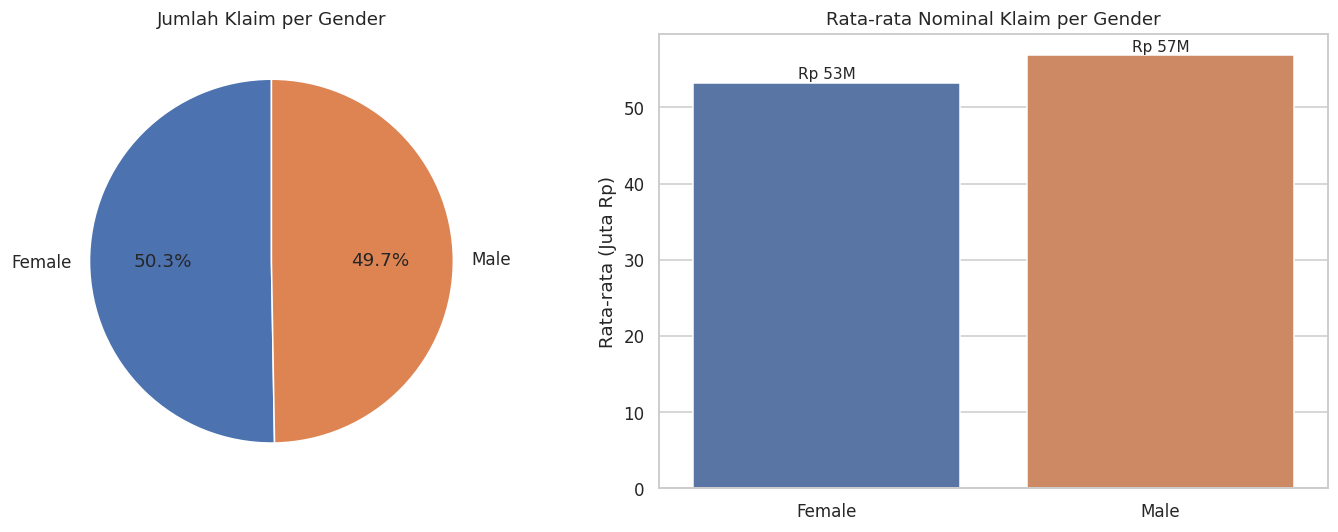

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Jumlah klaim per gender
gender_count = df['Gender'].value_counts()
gender_labels = {'M': 'Male', 'F': 'Female'}
gc = gender_count.rename(index=gender_labels)
axes[0].pie(gc, labels=gc.index, autopct='%1.1f%%', startangle=90,
            colors=['#4C72B0', '#DD8452'])
axes[0].set_title('Jumlah Klaim per Gender')

# Rata-rata nominal per gender
gender_nom = df.groupby('Gender')['Nominal Klaim Yang Disetujui'].mean().rename(index=gender_labels) / 1e6
sns.barplot(x=gender_nom.index, y=gender_nom.values, ax=axes[1], palette=['#4C72B0', '#DD8452'])
axes[1].set_title('Rata-rata Nominal Klaim per Gender')
axes[1].set_ylabel('Rata-rata (Juta Rp)')
axes[1].set_xlabel('')
for bar, val in zip(axes[1].patches, gender_nom.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'Rp {val:,.0f}M', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### 1.2 Distribusi Klaim per Usia

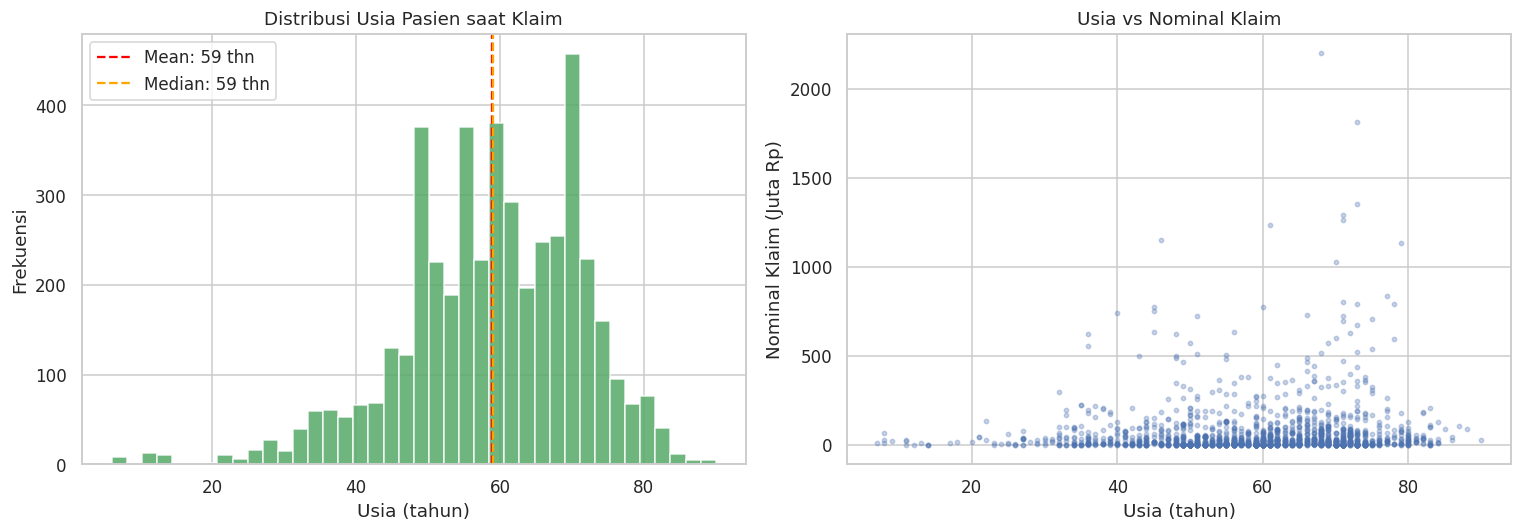

,Kelompok Usia,Jumlah Klaim,Avg Nominal (Juta),Total (Miliar)
0,0-17,38,45.7,1.73
1,18-30,71,30.0,2.13
2,31-45,482,54.3,26.17
3,46-60,1897,37.5,71.08
4,60+,2137,71.8,153.47


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram usia
axes[0].hist(df['Usia'], bins=40, color='#55A868', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Usia'].mean(), color='red', linestyle='--', label=f"Mean: {df['Usia'].mean():.0f} thn")
axes[0].axvline(df['Usia'].median(), color='orange', linestyle='--', label=f"Median: {df['Usia'].median():.0f} thn")
axes[0].set_title('Distribusi Usia Pasien saat Klaim')
axes[0].set_xlabel('Usia (tahun)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Usia vs Nominal (scatter)
sample = df.sample(min(2000, len(df)), random_state=42)
axes[1].scatter(sample['Usia'], sample['Nominal Klaim Yang Disetujui']/1e6,
               alpha=0.3, s=8, color='#4C72B0')
axes[1].set_title('Usia vs Nominal Klaim')
axes[1].set_xlabel('Usia (tahun)')
axes[1].set_ylabel('Nominal Klaim (Juta Rp)')

plt.tight_layout()
plt.show()

# Stats per kelompok usia
usia_bins = [0, 18, 30, 45, 60, 100]
usia_labels = ['0-17', '18-30', '31-45', '46-60', '60+']
df['Kelompok_Usia'] = pd.cut(df['Usia'], bins=usia_bins, labels=usia_labels)
usia_stats = df.groupby('Kelompok_Usia', observed=True).agg(
    Jumlah_Klaim=('Claim ID', 'count'),
    Avg_Nominal=('Nominal Klaim Yang Disetujui', 'mean'),
    Total_Nominal=('Nominal Klaim Yang Disetujui', 'sum')
).reset_index()
usia_stats['Avg_Nominal'] = (usia_stats['Avg_Nominal']/1e6).round(1)
usia_stats['Total_Nominal'] = (usia_stats['Total_Nominal']/1e9).round(2)
usia_stats.columns = ['Kelompok Usia', 'Jumlah Klaim', 'Avg Nominal (Juta)', 'Total (Miliar)']
usia_stats

### 1.3 Distribusi Klaim per Plan Code

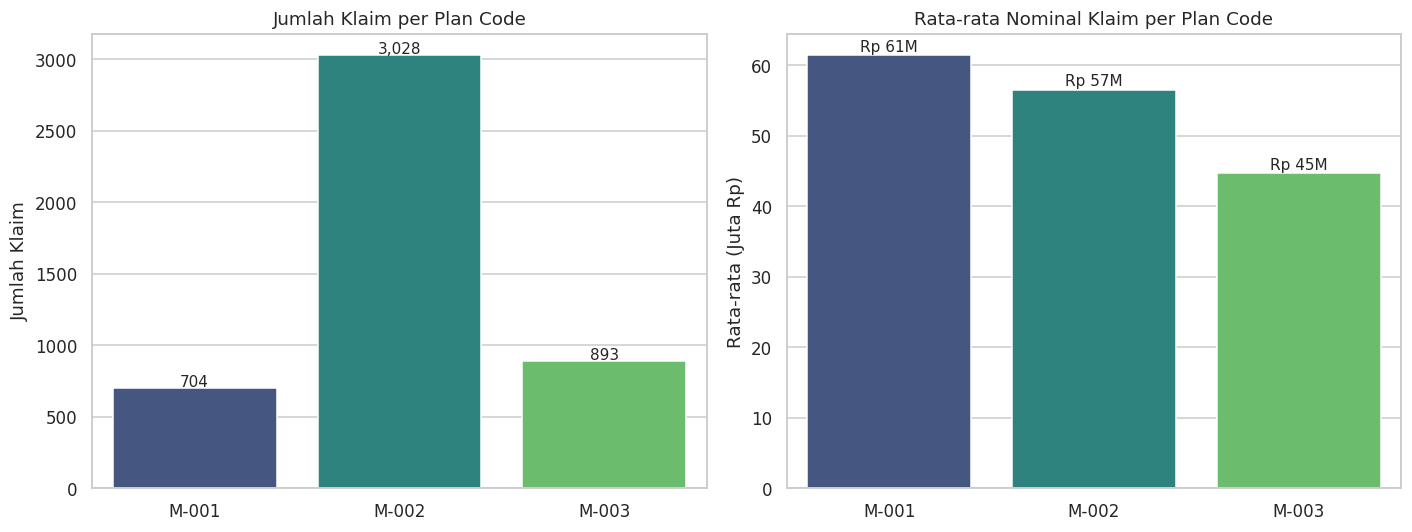

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Jumlah klaim per plan code
plan_count = df['Plan Code'].value_counts().sort_index()
sns.barplot(x=plan_count.index, y=plan_count.values, ax=axes[0], palette='viridis')
axes[0].set_title('Jumlah Klaim per Plan Code')
axes[0].set_ylabel('Jumlah Klaim')
axes[0].set_xlabel('')
for bar, val in zip(axes[0].patches, plan_count.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{val:,}', ha='center', fontsize=10)

# Avg nominal per plan code
plan_nom = df.groupby('Plan Code')['Nominal Klaim Yang Disetujui'].mean().sort_index() / 1e6
sns.barplot(x=plan_nom.index, y=plan_nom.values, ax=axes[1], palette='viridis')
axes[1].set_title('Rata-rata Nominal Klaim per Plan Code')
axes[1].set_ylabel('Rata-rata (Juta Rp)')
axes[1].set_xlabel('')
for bar, val in zip(axes[1].patches, plan_nom.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'Rp {val:,.0f}M', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### 1.4 Distribusi Klaim per Domisili (Top 15)

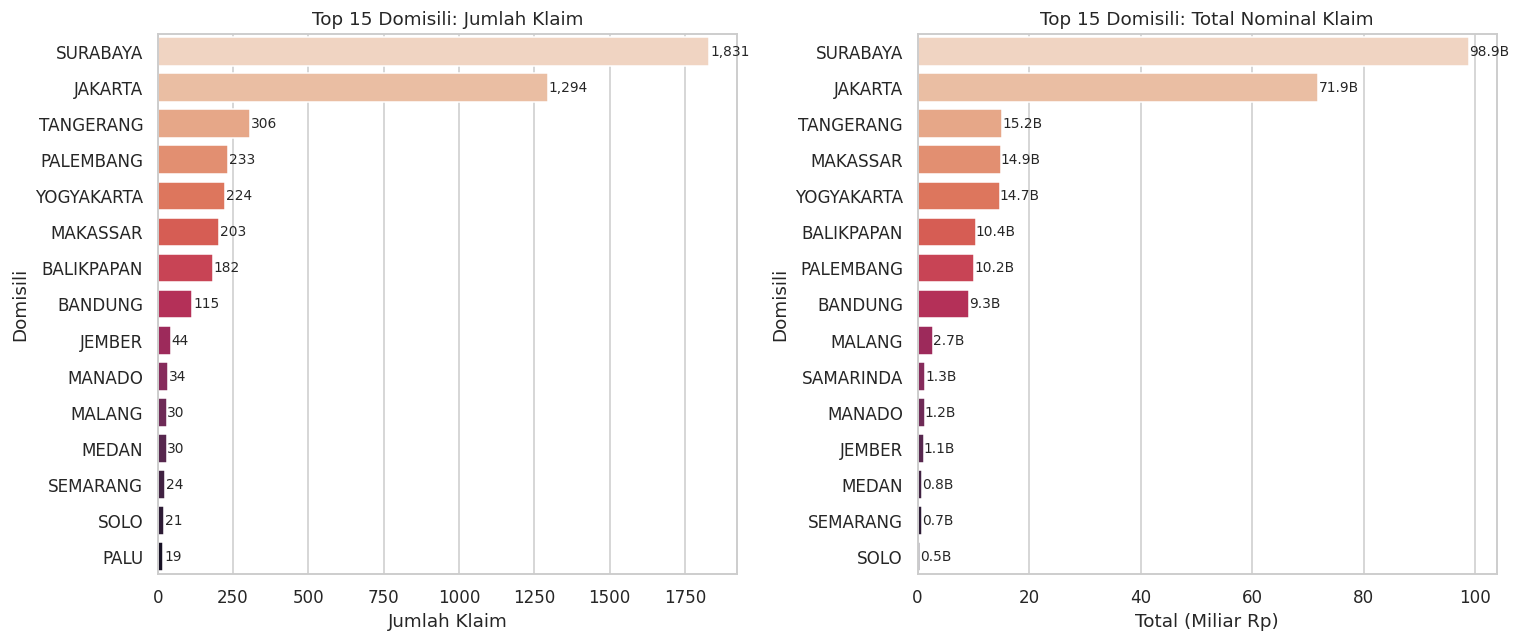

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 15 domisili by jumlah klaim
dom_count = df['Domisili'].value_counts().head(15)
sns.barplot(y=dom_count.index, x=dom_count.values, ax=axes[0], palette='rocket_r')
axes[0].set_title('Top 15 Domisili: Jumlah Klaim')
axes[0].set_xlabel('Jumlah Klaim')
for bar, val in zip(axes[0].patches, dom_count.values):
    axes[0].text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9)

# Top 15 domisili by total nominal
dom_nom = df.groupby('Domisili')['Nominal Klaim Yang Disetujui'].sum().sort_values(ascending=False).head(15) / 1e9
sns.barplot(y=dom_nom.index, x=dom_nom.values, ax=axes[1], palette='rocket_r')
axes[1].set_title('Top 15 Domisili: Total Nominal Klaim')
axes[1].set_xlabel('Total (Miliar Rp)')
for bar, val in zip(axes[1].patches, dom_nom.values):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}B', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 1.5 Cross-tab: Gender x Plan Code x Lokasi RS

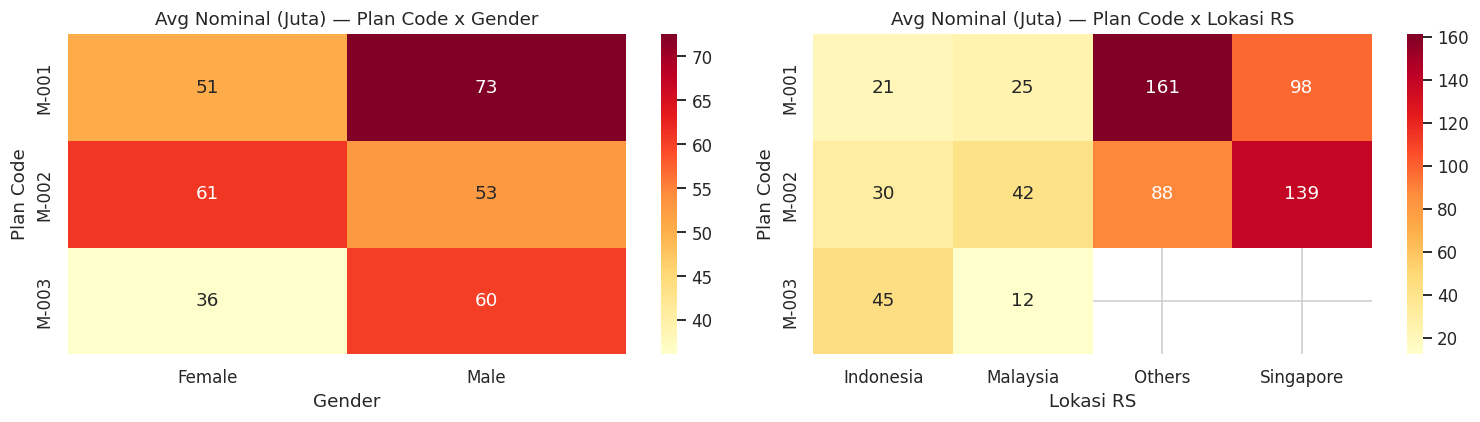

In [12]:
# Heatmap Gender x Plan Code
ct = pd.crosstab(df['Plan Code'], df['Gender'], values=df['Nominal Klaim Yang Disetujui'],
                 aggfunc='mean').rename(columns={'M': 'Male', 'F': 'Female'}) / 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(ct, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Avg Nominal (Juta) — Plan Code x Gender')

# Heatmap Plan Code x Lokasi RS (top 3 lokasi)
top_lok = df['Lokasi RS'].value_counts().head(3).index
ct2 = pd.crosstab(df['Plan Code'], df['Lokasi RS'].where(df['Lokasi RS'].isin(top_lok), 'Others'),
                  values=df['Nominal Klaim Yang Disetujui'], aggfunc='mean') / 1e6
sns.heatmap(ct2, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Avg Nominal (Juta) — Plan Code x Lokasi RS')

plt.tight_layout()
plt.show()

---
## Phase 2: Analisis Nominal & Coverage Mendalam

### 2.1 Distribusi Rasio Coverage (Klaim / Biaya RS)

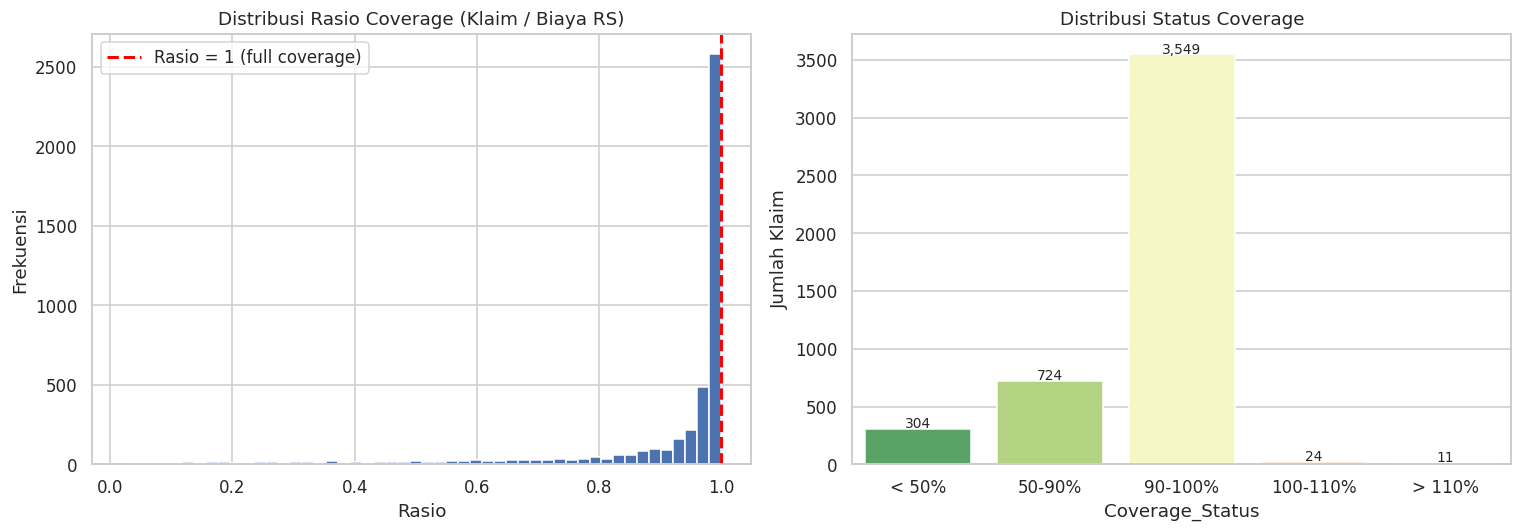

Klaim = Biaya RS  : 1,267 (27.4%)
Klaim < Biaya RS  : 3,322 (71.8%)
Klaim > Biaya RS  : 36 (0.8%)


In [13]:
rasio = df['Rasio_Coverage'].dropna()
rasio_capped = rasio[(rasio > 0) & (rasio <= rasio.quantile(0.99))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(rasio_capped, bins=50, color='#4C72B0', edgecolor='white')
axes[0].axvline(1, color='red', linestyle='--', linewidth=2, label='Rasio = 1 (full coverage)')
axes[0].set_title('Distribusi Rasio Coverage (Klaim / Biaya RS)')
axes[0].set_xlabel('Rasio')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Coverage category
df['Coverage_Status'] = pd.cut(df['Rasio_Coverage'],
    bins=[0, 0.5, 0.9, 1.0, 1.1, np.inf],
    labels=['< 50%', '50-90%', '90-100%', '100-110%', '> 110%'])
cov_count = df['Coverage_Status'].value_counts().sort_index()
sns.barplot(x=cov_count.index, y=cov_count.values, ax=axes[1], palette='RdYlGn_r')
axes[1].set_title('Distribusi Status Coverage')
axes[1].set_ylabel('Jumlah Klaim')
for bar, val in zip(axes[1].patches, cov_count.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{val:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Klaim = Biaya RS  : {(df["Selisih_Klaim"] == 0).sum():,} ({(df["Selisih_Klaim"] == 0).mean()*100:.1f}%)')
print(f'Klaim < Biaya RS  : {(df["Selisih_Klaim"] < 0).sum():,} ({(df["Selisih_Klaim"] < 0).mean()*100:.1f}%)')
print(f'Klaim > Biaya RS  : {(df["Selisih_Klaim"] > 0).sum():,} ({(df["Selisih_Klaim"] > 0).mean()*100:.1f}%)')

### 2.2 Investigasi Klaim Nominal = 0 & Klaim > Biaya RS

In [18]:
from IPython.display import display

print('=== 13 Klaim dengan Nominal Disetujui = 0 ===')
zero_klaim = df[df['Nominal Klaim Yang Disetujui'] == 0]
display(zero_klaim[['Claim ID', 'Nomor Polis', 'Reimburse/Cashless', 'Inpatient/Outpatient', 
                     'ICD Diagnosis', 'ICD_Group', 'Nominal Biaya RS Yang Terjadi', 
                     'Lokasi RS', 'Plan Code']].reset_index(drop=True))

print(f'\n=== {(df["Selisih_Klaim"] > 0).sum()} Klaim dimana Nominal > Biaya RS (Over-coverage) ===')
over = df[df['Selisih_Klaim'] > 0].sort_values('Selisih_Klaim', ascending=False)
display(over[['Claim ID', 'Nomor Polis', 'Nominal Klaim Yang Disetujui',
              'Nominal Biaya RS Yang Terjadi', 'Selisih_Klaim',
              'Lokasi RS', 'ICD_Group']].head(15).reset_index(drop=True))

=== 13 Klaim dengan Nominal Disetujui = 0 ===


,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD_Group,Nominal Biaya RS Yang Terjadi,Lokasi RS,Plan Code
0,C-0083-M,POL-2125,R,OP,H25.9,Mata/Telinga,75000.00,Indonesia,M-002
1,C-0085-M,POL-2125,R,OP,H25.9,Mata/Telinga,50000.00,Indonesia,M-002
2,C-0826-M,POL-3275,R,OP,S83,Cedera,2501363.16,Singapore,M-002
3,C-1793-M,POL-3328,R,IP,K58,Pencernaan,173287.00,Malaysia,M-002
4,C-1827-M,POL-3642,R,OP,K60.3,Pencernaan,88000.00,Indonesia,M-002
5,C-2497-M,POL-2721,R,OP,S33.7,Cedera,0.00,Singapore,M-001
6,C-2691-M,POL-0935,R,OP,K29.7,Pencernaan,18123820.00,Singapore,M-002
7,C-2840-M,POL-0856,R,IP,C34,Neoplasma/Kanker,3020970.00,Singapore,M-002
8,C-4713-M,POL-2778,R,OP,C50,Neoplasma/Kanker,1854301.08,Singapore,M-002
9,C-4715-M,POL-2778,R,OP,C50,Neoplasma/Kanker,2240990.34,Singapore,M-002



=== 36 Klaim dimana Nominal > Biaya RS (Over-coverage) ===


,Claim ID,Nomor Polis,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Selisih_Klaim,Lokasi RS,ICD_Group
0,C-0008-M,POL-0566,5.398718e+08,3.164563e+08,2.234155e+08,Singapore,Neoplasma/Kanker
1,C-1191-M,POL-0270,8.706156e+07,7.458850e+03,8.705410e+07,NaN,Lainnya
2,C-0010-M,POL-0964,3.229387e+07,0.000000e+00,3.229387e+07,Malaysia,Neoplasma/Kanker
3,C-1803-M,POL-0245,2.396094e+07,8.134000e+03,2.395281e+07,NaN,Lainnya
4,C-0001-M,POL-0176,2.809365e+07,6.143948e+06,2.194971e+07,Singapore,Neoplasma/Kanker
5,C-1758-M,POL-0158,1.714520e+07,8.058244e+05,1.633938e+07,Malaysia,Cedera
6,C-3799-M,POL-3903,3.275388e+08,3.140370e+08,1.350178e+07,Overseas,Kardiovaskular
7,C-4291-M,POL-3598,1.856154e+08,1.742050e+08,1.141038e+07,Overseas,Muskuloskeletal
8,C-3501-M,POL-0944,1.475149e+08,1.370476e+08,1.046737e+07,Overseas,Kardiovaskular
9,C-5756-M,POL-3288,1.269277e+08,1.170609e+08,9.866815e+06,Overseas,Neoplasma/Kanker


### 2.3 Nominal per ICD Group

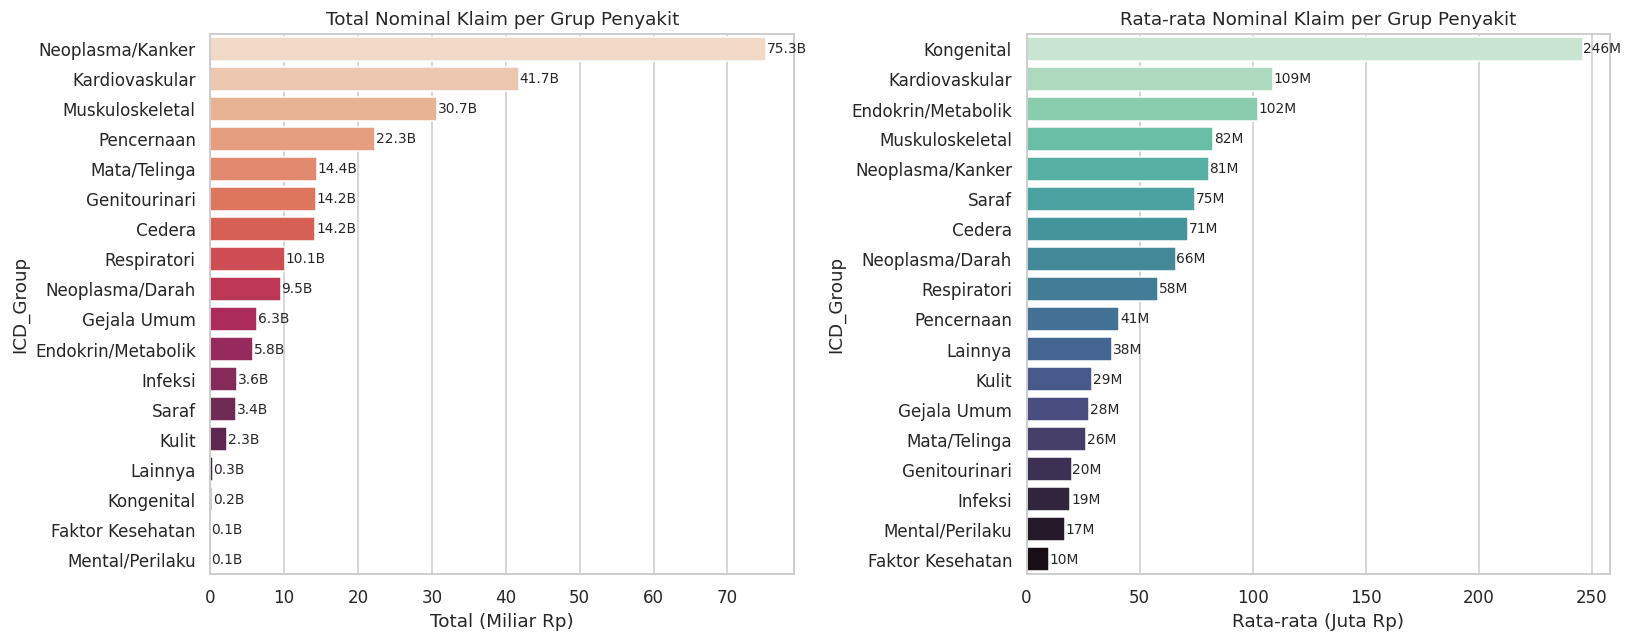

In [19]:
icd_stats = df.groupby('ICD_Group').agg(
    Jumlah=('Claim ID', 'count'),
    Avg_Nominal=('Nominal Klaim Yang Disetujui', 'mean'),
    Total_Nominal=('Nominal Klaim Yang Disetujui', 'sum')
).sort_values('Total_Nominal', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Total nominal per ICD Group
sns.barplot(y=icd_stats.index, x=icd_stats['Total_Nominal']/1e9, ax=axes[0], palette='rocket_r')
axes[0].set_title('Total Nominal Klaim per Grup Penyakit')
axes[0].set_xlabel('Total (Miliar Rp)')
for bar, val in zip(axes[0].patches, icd_stats['Total_Nominal']/1e9):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}B', va='center', fontsize=9)

# Avg nominal per ICD Group
icd_avg = icd_stats.sort_values('Avg_Nominal', ascending=False)
sns.barplot(y=icd_avg.index, x=icd_avg['Avg_Nominal']/1e6, ax=axes[1], palette='mako_r')
axes[1].set_title('Rata-rata Nominal Klaim per Grup Penyakit')
axes[1].set_xlabel('Rata-rata (Juta Rp)')
for bar, val in zip(axes[1].patches, icd_avg['Avg_Nominal']/1e6):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.0f}M', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### total claim per grup

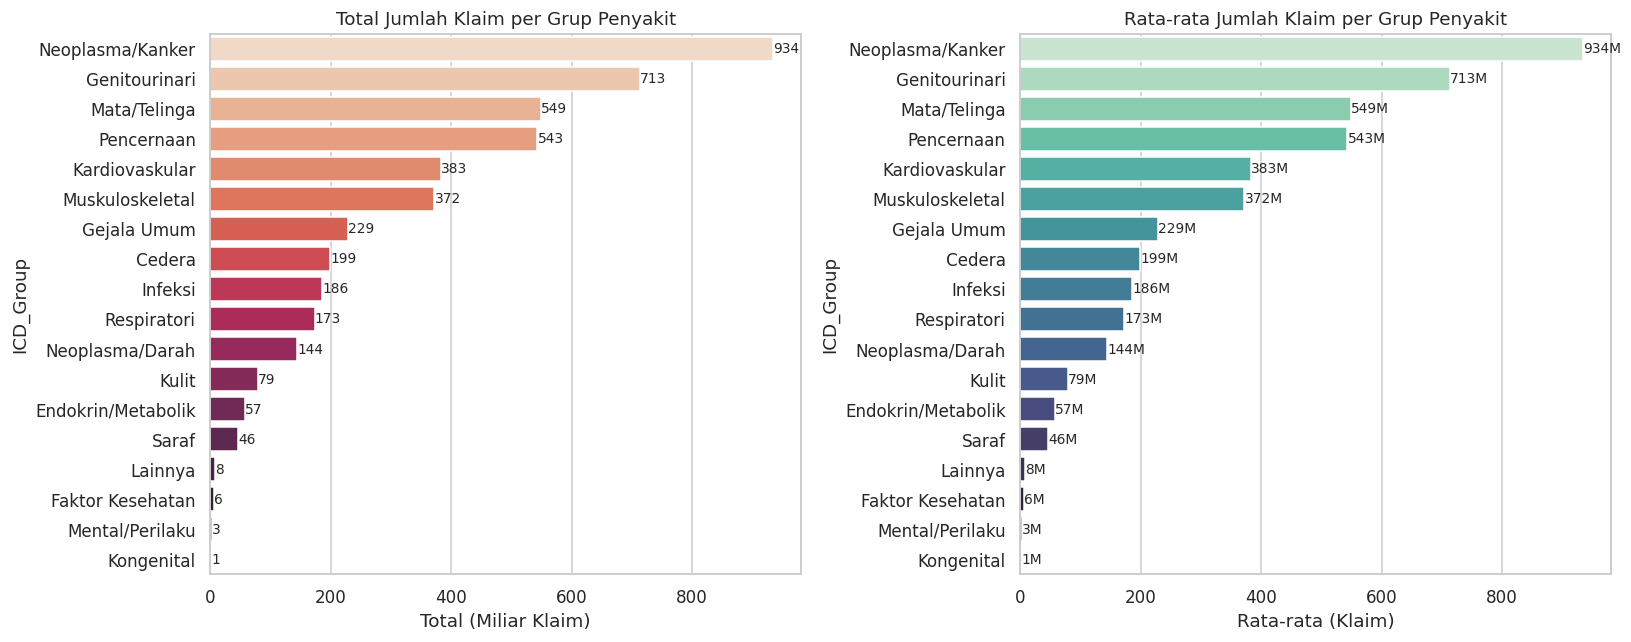

In [41]:
icd_stats = df.groupby('ICD_Group').agg(
    Jumlah=('Claim ID', 'count')
).sort_values('Jumlah', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Total nominal per ICD Group
sns.barplot(y=icd_stats.index, x=icd_stats['Jumlah'], ax=axes[0], palette='rocket_r')
axes[0].set_title('Total Jumlah Klaim per Grup Penyakit')
axes[0].set_xlabel('Total (Miliar Klaim)')
for bar, val in zip(axes[0].patches, icd_stats['Jumlah']):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:.0f}', va='center', fontsize=9)

# Avg nominal per ICD Group
icd_avg = icd_stats.sort_values('Jumlah', ascending=False)
sns.barplot(y=icd_avg.index, x=icd_avg['Jumlah'], ax=axes[1], palette='mako_r')
axes[1].set_title('Rata-rata Jumlah Klaim per Grup Penyakit')
axes[1].set_xlabel('Rata-rata (Klaim)')
for bar, val in zip(axes[1].patches, icd_avg['Jumlah']):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.0f}M', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 2.4 Boxplot Nominal per Lokasi RS & per Jenis Rawat

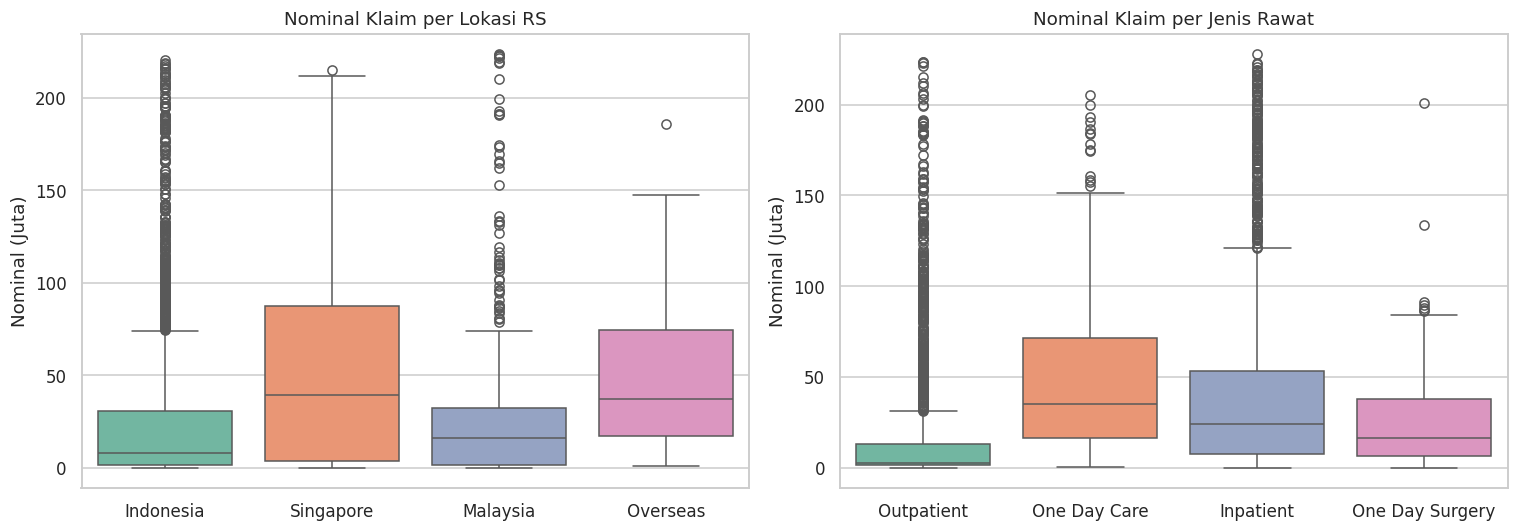

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nominal per Lokasi RS (top 4)
top4_lok = df['Lokasi RS'].value_counts().head(4).index.tolist()
df_lok = df[df['Lokasi RS'].isin(top4_lok)].copy()
df_lok['Nominal (Juta)'] = df_lok['Nominal Klaim Yang Disetujui'] / 1e6
q95 = df_lok['Nominal (Juta)'].quantile(0.95)
sns.boxplot(data=df_lok[df_lok['Nominal (Juta)'] <= q95],
            x='Lokasi RS', y='Nominal (Juta)', ax=axes[0],
            order=['Indonesia', 'Singapore', 'Malaysia', 'Overseas'], palette='Set2')
axes[0].set_title('Nominal Klaim per Lokasi RS')
axes[0].set_xlabel('')

# Nominal per jenis rawat
ip_map = {'IP': 'Inpatient', 'OP': 'Outpatient', 'ODC': 'One Day Care', 'ODS': 'One Day Surgery'}
df_ip = df.dropna(subset=['Inpatient/Outpatient']).copy()
df_ip['Jenis_Rawat'] = df_ip['Inpatient/Outpatient'].map(ip_map)
df_ip['Nominal (Juta)'] = df_ip['Nominal Klaim Yang Disetujui'] / 1e6
q95_ip = df_ip['Nominal (Juta)'].quantile(0.95)
sns.boxplot(data=df_ip[df_ip['Nominal (Juta)'] <= q95_ip],
            x='Jenis_Rawat', y='Nominal (Juta)', ax=axes[1], palette='Set2')
axes[1].set_title('Nominal Klaim per Jenis Rawat')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

---
## Phase 3: Analisis Pola Klaim & Repeat Claimers

### 3.1 Distribusi Jumlah Klaim per Polis

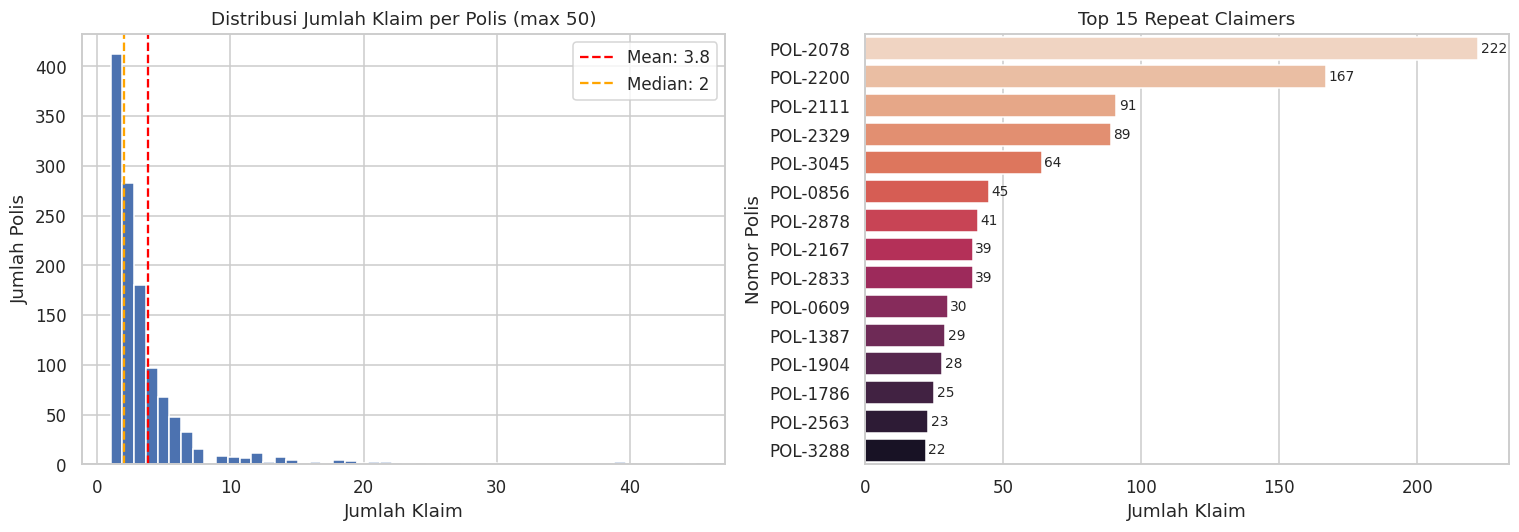

Statistik klaim per polis:
count    1210.000000
mean        3.822314
std         9.652301
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max       222.000000


In [21]:
klaim_per_polis = df['Nomor Polis'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (capped at 50 for readability)
kpp_cap = klaim_per_polis[klaim_per_polis <= 50]
axes[0].hist(kpp_cap, bins=50, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribusi Jumlah Klaim per Polis (max 50)')
axes[0].set_xlabel('Jumlah Klaim')
axes[0].set_ylabel('Jumlah Polis')
axes[0].axvline(klaim_per_polis.mean(), color='red', linestyle='--',
               label=f"Mean: {klaim_per_polis.mean():.1f}")
axes[0].axvline(klaim_per_polis.median(), color='orange', linestyle='--',
               label=f"Median: {klaim_per_polis.median():.0f}")
axes[0].legend()

# Top 15 repeat claimers
top15 = klaim_per_polis.head(15)
sns.barplot(y=top15.index, x=top15.values, ax=axes[1], palette='rocket_r')
axes[1].set_title('Top 15 Repeat Claimers')
axes[1].set_xlabel('Jumlah Klaim')
for bar, val in zip(axes[1].patches, top15.values):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{val}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Statistik klaim per polis:')
print(klaim_per_polis.describe().to_string())

### 3.2 Profil Top 10 Repeat Claimers

In [22]:
top10_polis = klaim_per_polis.head(10).index.tolist()
top10_df = df[df['Nomor Polis'].isin(top10_polis)]

profil = top10_df.groupby('Nomor Polis').agg(
    Jumlah_Klaim=('Claim ID', 'count'),
    Total_Nominal=('Nominal Klaim Yang Disetujui', 'sum'),
    Avg_Nominal=('Nominal Klaim Yang Disetujui', 'mean'),
    Gender=('Gender', 'first'),
    Usia=('Usia', 'first'),
    Plan=('Plan Code', 'first'),
    Domisili=('Domisili', 'first'),
    Top_Diagnosis=('ICD_Group', lambda x: x.value_counts().index[0]),
    Lokasi_Favorit=('Lokasi RS', lambda x: x.value_counts().index[0]),
    Periode=('Tanggal Pasien Masuk RS', lambda x: f"{x.min().strftime('%Y-%m')} s/d {x.max().strftime('%Y-%m')}")
).sort_values('Jumlah_Klaim', ascending=False)
profil['Total_Nominal'] = (profil['Total_Nominal']/1e9).round(2)
profil['Avg_Nominal'] = (profil['Avg_Nominal']/1e6).round(1)
profil.columns = ['Jml Klaim', 'Total (Miliar)', 'Avg (Juta)', 'Gender', 'Usia',
                  'Plan', 'Domisili', 'Diagnosis Utama', 'Lokasi RS Favorit', 'Periode']
profil

,Jml Klaim,Total (Miliar),Avg (Juta),Gender,Usia,Plan,Domisili,Diagnosis Utama,Lokasi RS Favorit,Periode
Nomor Polis,,,,,,,,,,
POL-2078,222,1.73,7.8,M,56,M-002,SURABAYA,Genitourinari,Indonesia,2024-01 s/d 2025-07
POL-2200,167,0.40,2.4,F,50,M-003,JAKARTA,Genitourinari,Indonesia,2024-01 s/d 2025-07
POL-2111,91,0.59,6.4,F,59,M-002,SURABAYA,Genitourinari,Indonesia,2024-10 s/d 2025-07
POL-2329,89,1.89,21.3,M,51,M-002,SURABAYA,Neoplasma/Kanker,Indonesia,2024-01 s/d 2025-07
POL-3045,64,0.10,1.5,M,55,M-002,PALEMBANG,Genitourinari,Indonesia,2024-01 s/d 2025-03
POL-0856,45,5.97,132.7,F,50,M-002,SURABAYA,Neoplasma/Kanker,Singapore,2024-01 s/d 2025-07
POL-2878,41,2.00,48.8,F,62,M-001,BALIKPAPAN,Neoplasma/Kanker,Singapore,2024-02 s/d 2025-06
POL-2167,39,1.01,26.0,F,45,M-002,JAKARTA,Neoplasma/Kanker,Indonesia,2024-01 s/d 2025-07
POL-2833,39,2.35,60.1,F,72,M-002,BALIKPAPAN,Neoplasma/Kanker,Singapore,2024-01 s/d 2025-07


In [24]:
#detail diagnosis
top10_polis = klaim_per_polis.head(10).index.tolist()
top10_df = df[df['Nomor Polis'].isin(top10_polis)]

profil = top10_df.groupby('Nomor Polis').agg(
    Jumlah_Klaim=('Claim ID', 'count'),
    Total_Nominal=('Nominal Klaim Yang Disetujui', 'sum'),
    Avg_Nominal=('Nominal Klaim Yang Disetujui', 'mean'),
    Gender=('Gender', 'first'),
    Usia=('Usia', 'first'),
    Plan=('Plan Code', 'first'),
    Domisili=('Domisili', 'first'),
    Top_Diagnosis=('ICD_Group', lambda x: x.value_counts().index[0]),
    detail_Diagnosis=('ICD Diagnosis', lambda x: x.value_counts().index[0]),
    Lokasi_Favorit=('Lokasi RS', lambda x: x.value_counts().index[0]),
    Periode=('Tanggal Pasien Masuk RS', lambda x: f"{x.min().strftime('%Y-%m')} s/d {x.max().strftime('%Y-%m')}")
).sort_values('Jumlah_Klaim', ascending=False)
profil['Total_Nominal'] = (profil['Total_Nominal']/1e9).round(2)
profil['Avg_Nominal'] = (profil['Avg_Nominal']/1e6).round(1)
profil.columns = ['Jml Klaim', 'Total (Miliar)', 'Avg (Juta)', 'Gender', 'Usia',
                  'Plan', 'Domisili', 'Diagnosis Utama','Detail Diagnosis', 'Lokasi RS Favorit', 'Periode']
profil

,Jml Klaim,Total (Miliar),Avg (Juta),Gender,Usia,Plan,Domisili,Diagnosis Utama,Detail Diagnosis,Lokasi RS Favorit,Periode
Nomor Polis,,,,,,,,,,,
POL-2078,222,1.73,7.8,M,56,M-002,SURABAYA,Genitourinari,N18.0,Indonesia,2024-01 s/d 2025-07
POL-2200,167,0.40,2.4,F,50,M-003,JAKARTA,Genitourinari,N18.0,Indonesia,2024-01 s/d 2025-07
POL-2111,91,0.59,6.4,F,59,M-002,SURABAYA,Genitourinari,N18.0,Indonesia,2024-10 s/d 2025-07
POL-2329,89,1.89,21.3,M,51,M-002,SURABAYA,Neoplasma/Kanker,C19,Indonesia,2024-01 s/d 2025-07
POL-3045,64,0.10,1.5,M,55,M-002,PALEMBANG,Genitourinari,N18.6,Indonesia,2024-01 s/d 2025-03
POL-0856,45,5.97,132.7,F,50,M-002,SURABAYA,Neoplasma/Kanker,C34.9,Singapore,2024-01 s/d 2025-07
POL-2878,41,2.00,48.8,F,62,M-001,BALIKPAPAN,Neoplasma/Kanker,C90.0,Singapore,2024-02 s/d 2025-06
POL-2167,39,1.01,26.0,F,45,M-002,JAKARTA,Neoplasma/Kanker,C50,Indonesia,2024-01 s/d 2025-07
POL-2833,39,2.35,60.1,F,72,M-002,BALIKPAPAN,Neoplasma/Kanker,C25,Singapore,2024-01 s/d 2025-07


### 3.3 Pola Diagnosis Repeat Claimers

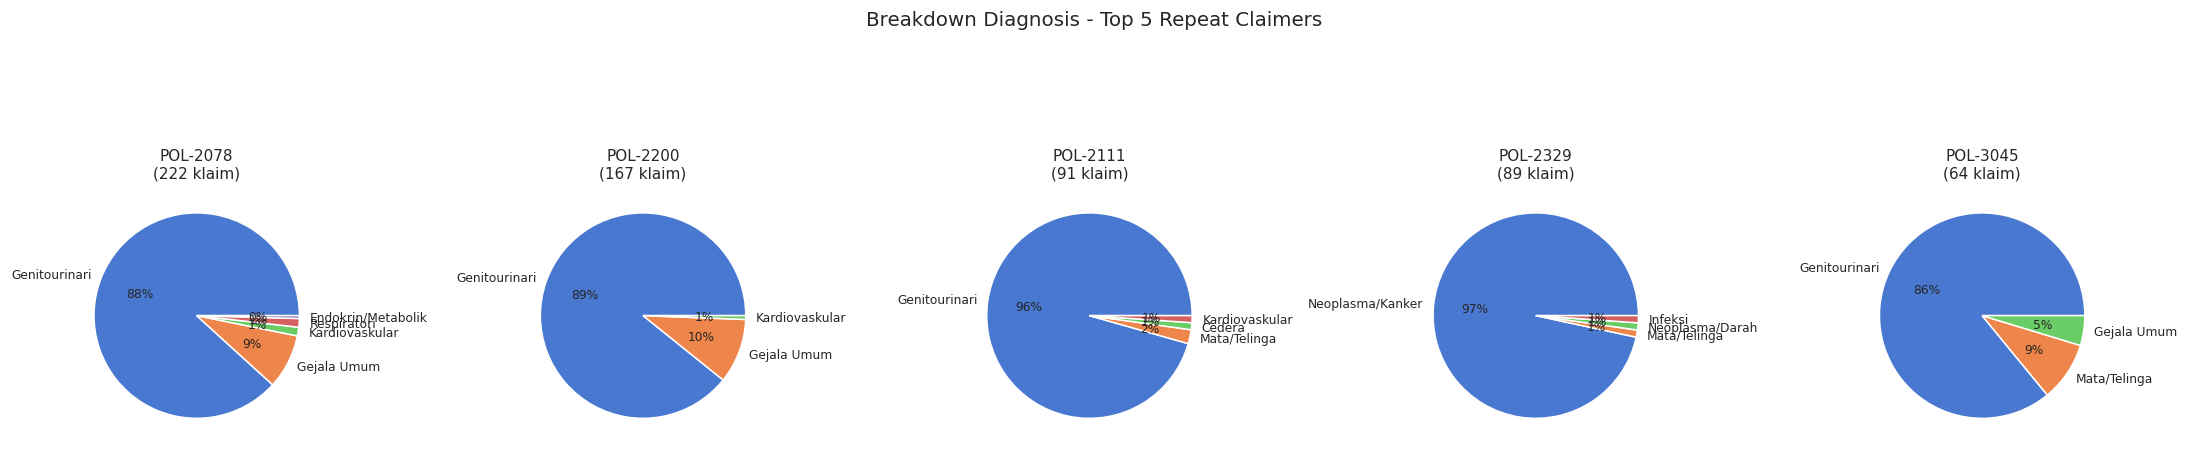

In [25]:
# Top 5 repeat claimers - breakdown diagnosis
top5_polis = klaim_per_polis.head(5).index.tolist()

fig, axes = plt.subplots(1, len(top5_polis), figsize=(20, 5))
for ax, polis in zip(axes, top5_polis):
    data_p = df[df['Nomor Polis'] == polis]
    icd_cnt = data_p['ICD_Group'].value_counts().head(5)
    ax.pie(icd_cnt, labels=icd_cnt.index, autopct='%1.0f%%', textprops={'fontsize': 8})
    ax.set_title(f'{polis}\n({len(data_p)} klaim)', fontsize=10)

plt.suptitle('Breakdown Diagnosis - Top 5 Repeat Claimers', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 3.4 Frekuensi Klaim vs Plan Code

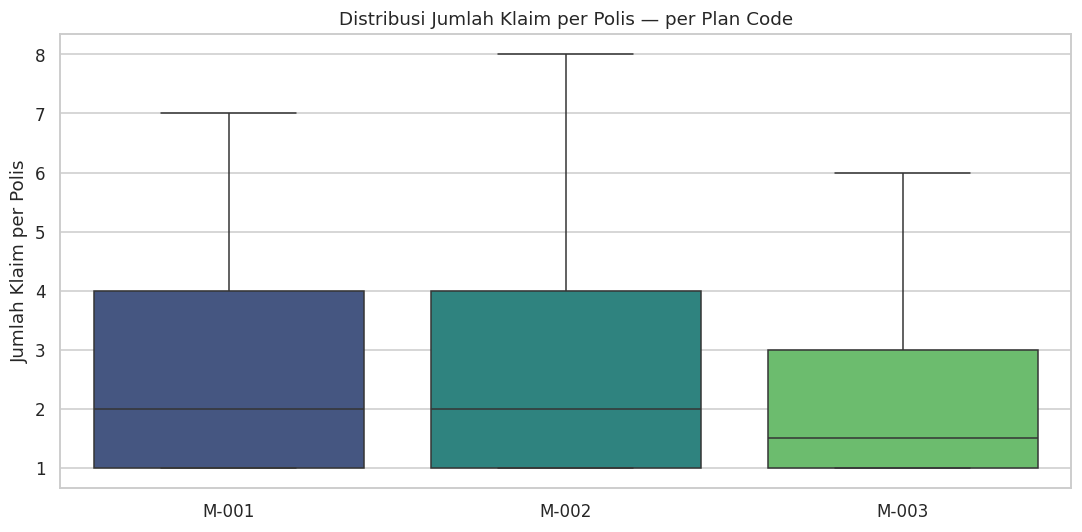

,Mean Klaim/Polis,Median,Max,Jumlah Polis
Plan Code,,,,
M-001,4.0,2.0,41,176
M-002,4.1,2.0,222,730
M-003,2.9,1.5,167,304


In [26]:
kpp_plan = df.groupby(['Nomor Polis', 'Plan Code']).size().reset_index(name='Jumlah_Klaim')

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=kpp_plan, x='Plan Code', y='Jumlah_Klaim', ax=ax, palette='viridis',
           showfliers=False)
ax.set_title('Distribusi Jumlah Klaim per Polis — per Plan Code')
ax.set_ylabel('Jumlah Klaim per Polis')
ax.set_xlabel('')

# Stats table
plan_freq = kpp_plan.groupby('Plan Code')['Jumlah_Klaim'].agg(['mean', 'median', 'max', 'count'])
plan_freq.columns = ['Mean Klaim/Polis', 'Median', 'Max', 'Jumlah Polis']
plan_freq['Mean Klaim/Polis'] = plan_freq['Mean Klaim/Polis'].round(1)

plt.tight_layout()
plt.show()
plan_freq

---
## Phase 4: Analisis Temporal (Time Series)

### 4.1 Tren Bulanan per Lokasi RS

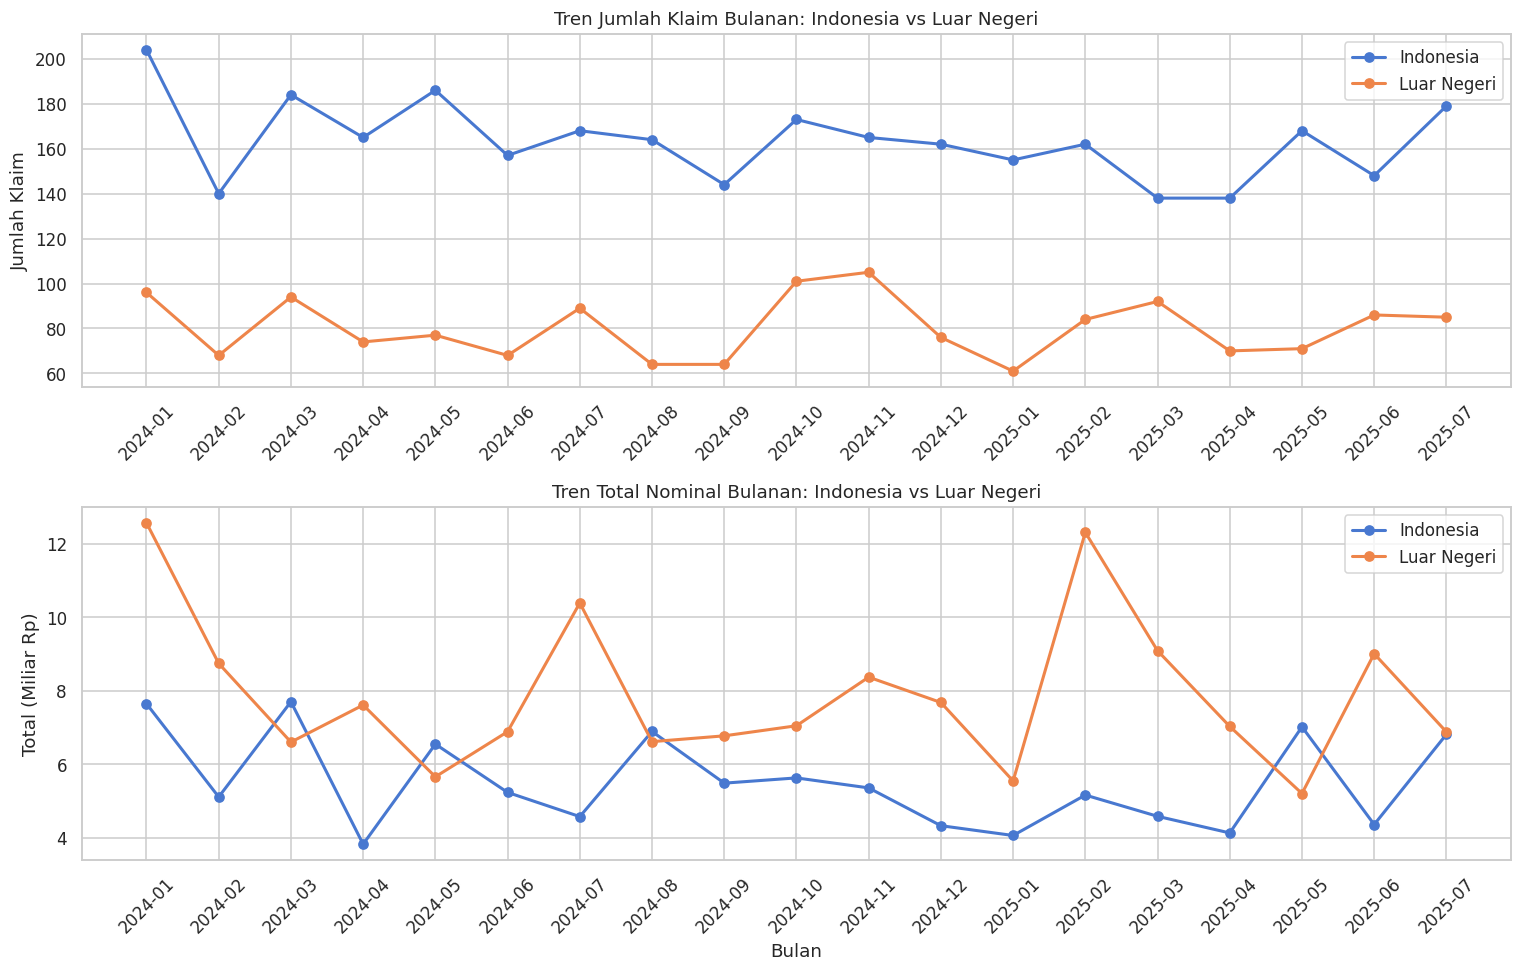

In [27]:
# Tren per lokasi (Indonesia vs Luar Negeri)
df['Lokasi_Group'] = df['Lokasi RS'].apply(lambda x: 'Indonesia' if x == 'Indonesia' else 'Luar Negeri')
trend_lok = df.groupby(['Bulan', 'Lokasi_Group']).agg(
    Jumlah=('Claim ID', 'count'),
    Total=('Nominal Klaim Yang Disetujui', 'sum')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

for lokasi in ['Indonesia', 'Luar Negeri']:
    data = trend_lok[trend_lok['Lokasi_Group'] == lokasi]
    axes[0].plot(data['Bulan'], data['Jumlah'], marker='o', label=lokasi, linewidth=2)
    axes[1].plot(data['Bulan'], data['Total']/1e9, marker='o', label=lokasi, linewidth=2)

axes[0].set_title('Tren Jumlah Klaim Bulanan: Indonesia vs Luar Negeri')
axes[0].set_ylabel('Jumlah Klaim')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].set_title('Tren Total Nominal Bulanan: Indonesia vs Luar Negeri')
axes[1].set_ylabel('Total (Miliar Rp)')
axes[1].set_xlabel('Bulan')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 4.2 Tren Bulanan per Jenis Rawat

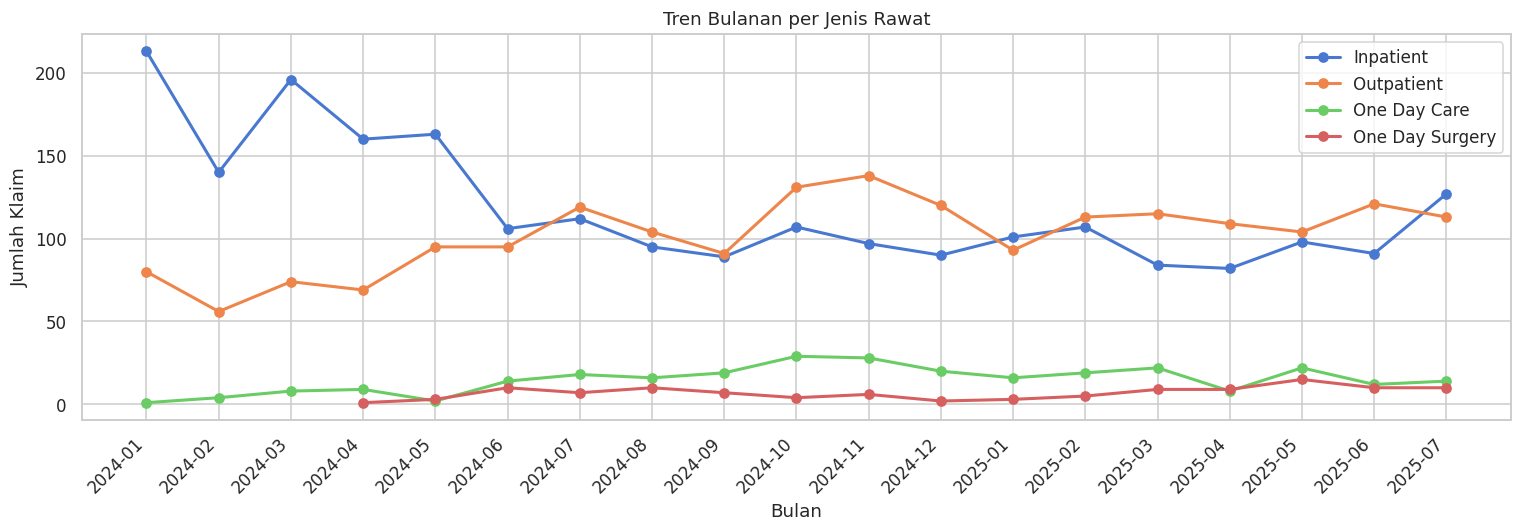

In [28]:
trend_ip = df.dropna(subset=['Inpatient/Outpatient']).groupby(
    ['Bulan', 'Inpatient/Outpatient']).size().reset_index(name='Jumlah')

fig, ax = plt.subplots(figsize=(14, 5))
for jenis in ['IP', 'OP', 'ODC', 'ODS']:
    data = trend_ip[trend_ip['Inpatient/Outpatient'] == jenis]
    label = {'IP': 'Inpatient', 'OP': 'Outpatient', 'ODC': 'One Day Care', 'ODS': 'One Day Surgery'}[jenis]
    ax.plot(data['Bulan'], data['Jumlah'], marker='o', label=label, linewidth=2)

ax.set_title('Tren Bulanan per Jenis Rawat')
ax.set_ylabel('Jumlah Klaim')
ax.set_xlabel('Bulan')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4.3 Heatmap Hari dalam Minggu vs Bulan

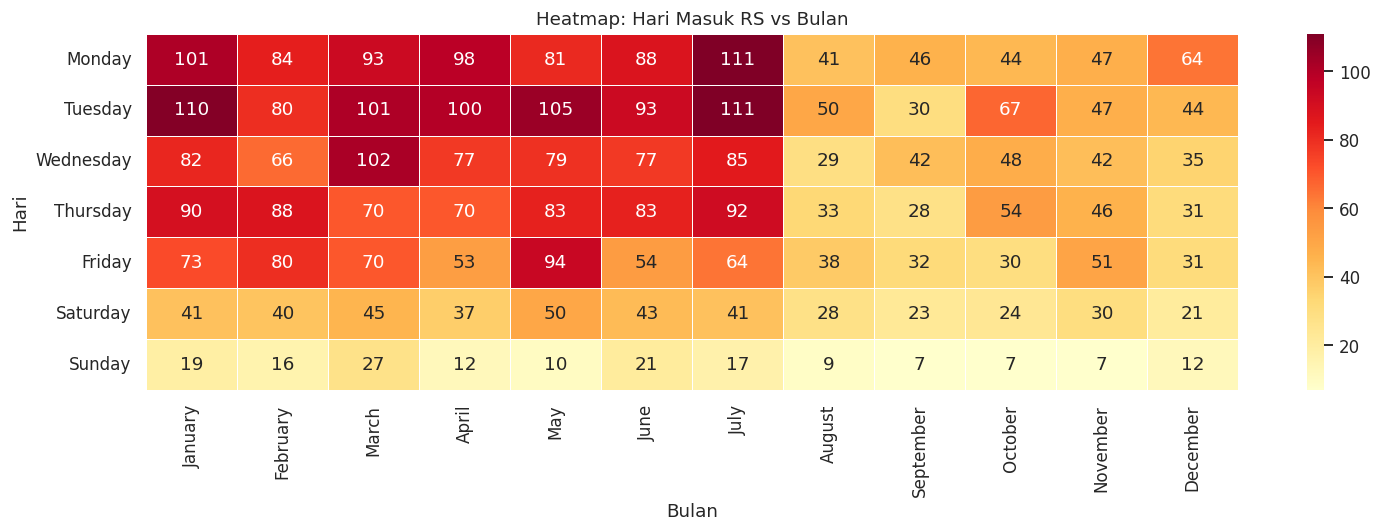

In [29]:
df['Month'] = df['Tanggal Pasien Masuk RS'].dt.month_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = pd.crosstab(df['DayOfWeek'], df['Month'])
# Reorder
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
month_present = [m for m in month_order if m in heatmap_data.columns]
heatmap_data = heatmap_data.reindex(index=day_order, columns=month_present)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Heatmap: Hari Masuk RS vs Bulan')
ax.set_ylabel('Hari')
ax.set_xlabel('Bulan')
plt.tight_layout()
plt.show()

### 4.4 Claim Processing Time

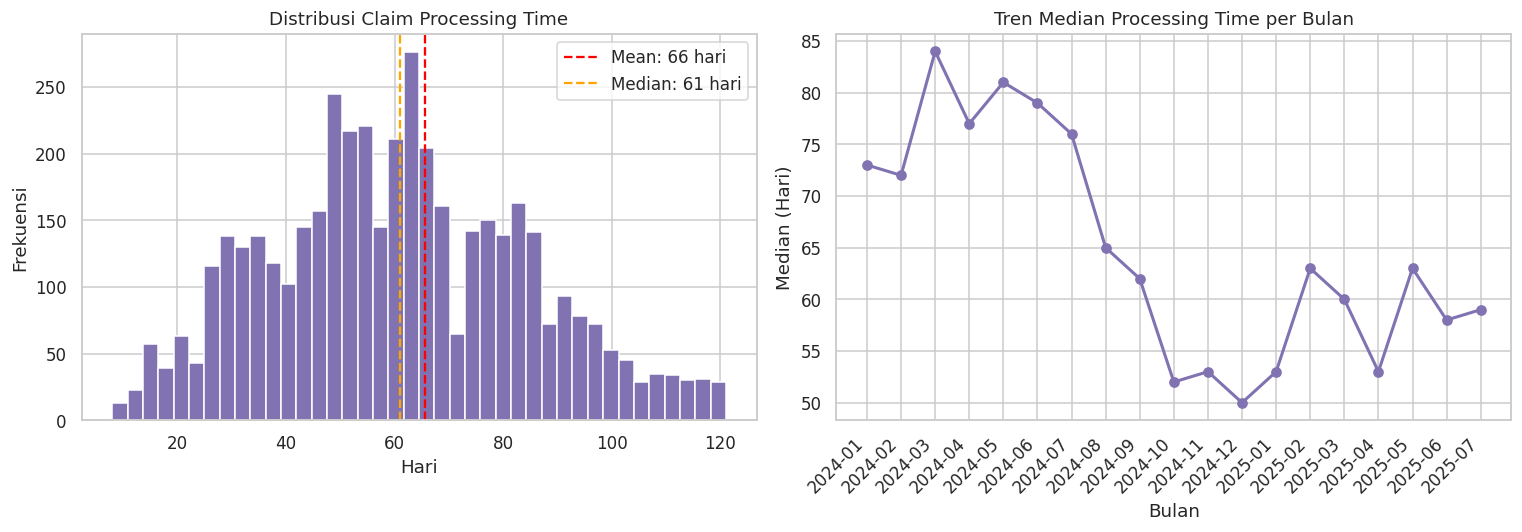

Processing Time Stats:
  Mean   : 66 hari
  Median : 61 hari
  Max    : 606 hari


In [30]:
proc = df.dropna(subset=['Processing_Days']).copy()
proc = proc[proc['Processing_Days'] >= 0]  # filter anomali

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
proc_capped = proc[proc['Processing_Days'] <= proc['Processing_Days'].quantile(0.95)]
axes[0].hist(proc_capped['Processing_Days'], bins=40, color='#8172B2', edgecolor='white')
axes[0].axvline(proc['Processing_Days'].mean(), color='red', linestyle='--',
               label=f"Mean: {proc['Processing_Days'].mean():.0f} hari")
axes[0].axvline(proc['Processing_Days'].median(), color='orange', linestyle='--',
               label=f"Median: {proc['Processing_Days'].median():.0f} hari")
axes[0].set_title('Distribusi Claim Processing Time')
axes[0].set_xlabel('Hari')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Tren bulanan processing time
proc_trend = proc.groupby('Bulan')['Processing_Days'].median().reset_index()
axes[1].plot(proc_trend['Bulan'], proc_trend['Processing_Days'], marker='o', color='#8172B2', linewidth=2)
axes[1].set_title('Tren Median Processing Time per Bulan')
axes[1].set_xlabel('Bulan')
axes[1].set_ylabel('Median (Hari)')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print(f'Processing Time Stats:')
print(f'  Mean   : {proc["Processing_Days"].mean():.0f} hari')
print(f'  Median : {proc["Processing_Days"].median():.0f} hari')
print(f'  Max    : {proc["Processing_Days"].max():.0f} hari')

### processing time vs jumlah claim

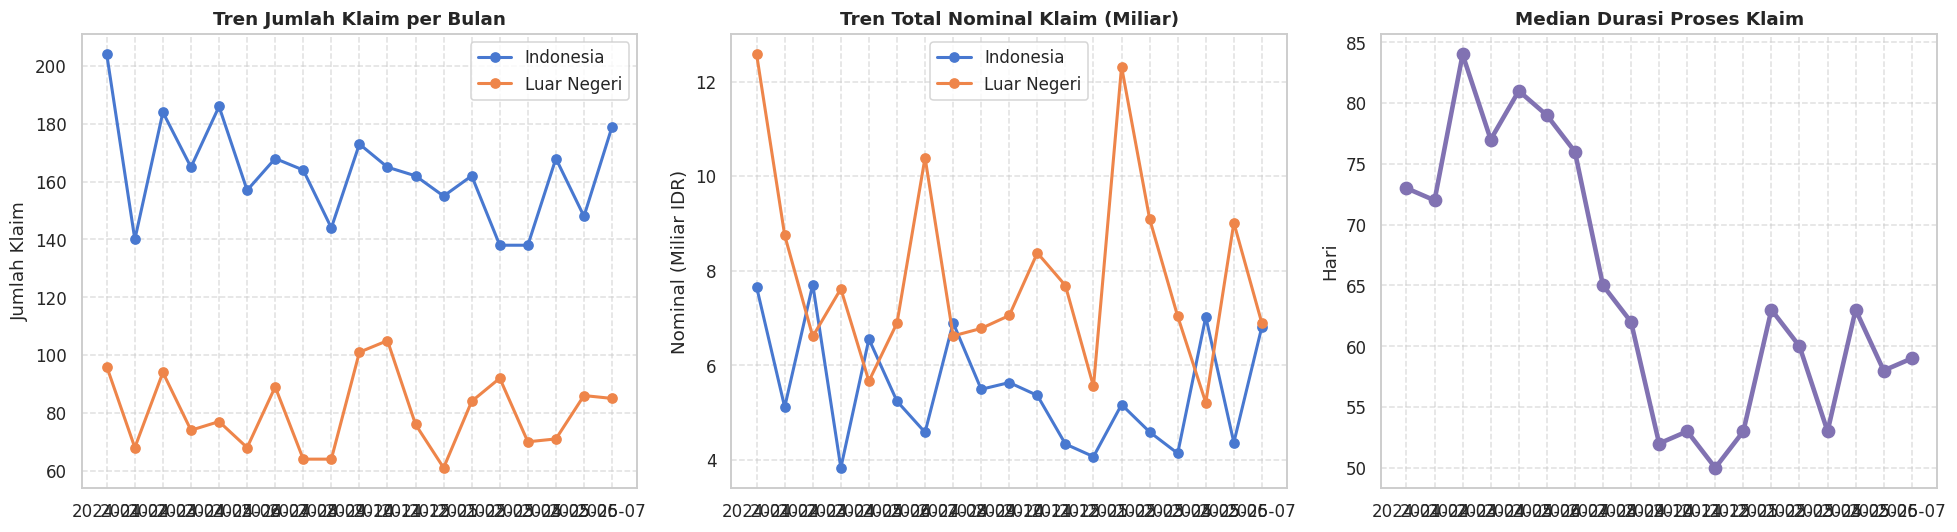

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Inisialisasi Figure dan Axes (Asumsi: 1 baris, 3 kolom)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 0: Tren Jumlah Klaim ---
for lokasi in ['Indonesia', 'Luar Negeri']:
    data = trend_lok[trend_lok['Lokasi_Group'] == lokasi]
    axes[0].plot(data['Bulan'], data['Jumlah'], marker='o', label=lokasi, linewidth=2)
axes[0].set_title('Tren Jumlah Klaim per Bulan', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Klaim')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- Plot 1: Tren Total Nominal (dalam Miliar) ---
for lokasi in ['Indonesia', 'Luar Negeri']:
    data = trend_lok[trend_lok['Lokasi_Group'] == lokasi]
    axes[1].plot(data['Bulan'], data['Total']/1e9, marker='o', label=lokasi, linewidth=2)
axes[1].set_title('Tren Total Nominal Klaim (Miliar)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Nominal (Miliar IDR)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: Tren Waktu Proses (Processing Time) ---
# Menggunakan median agar tidak terdistorsi oleh outlier
proc_trend = proc.groupby('Bulan')['Processing_Days'].median().reset_index()
axes[2].plot(proc_trend['Bulan'], proc_trend['Processing_Days'], 
             marker='o', color='#8172B2', linewidth=3, markersize=8)
axes[2].set_title('Median Durasi Proses Klaim', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Hari')
axes[2].grid(True, linestyle='--', alpha=0.6)

# 2. Finishing touch
plt.tight_layout()
plt.show()

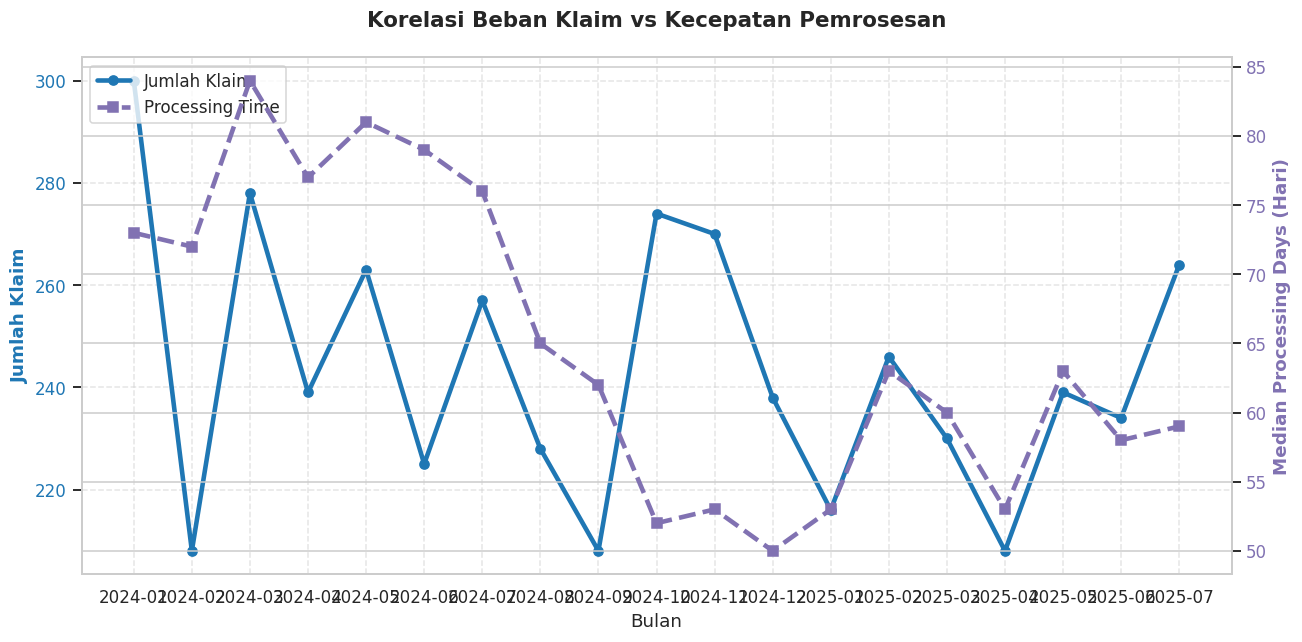

In [35]:
import matplotlib.pyplot as plt

# 1. Siapkan Data Agregat Total (Gabungan Indonesia & Luar Negeri)
# Kita perlu total jumlah klaim per bulan untuk dibandingkan dengan median durasi proses
total_claim_trend = trend_lok.groupby('Bulan')['Jumlah'].sum().reset_index()
proc_trend = proc.groupby('Bulan')['Processing_Days'].median().reset_index()

# 2. Inisialisasi Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Plot 1: Jumlah Klaim (Sumbu Y Kiri) ---
color_claim = '#1f77b4' # Biru
ax1.set_xlabel('Bulan')
ax1.set_ylabel('Jumlah Klaim', color=color_claim, fontsize=12, fontweight='bold')
line1 = ax1.plot(total_claim_trend['Bulan'], total_claim_trend['Jumlah'], 
                 marker='o', color=color_claim, linewidth=3, label='Jumlah Klaim')
ax1.tick_params(axis='y', labelcolor=color_claim)
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Plot 2: Processing Time (Sumbu Y Kanan) ---
ax2 = ax1.twinx() # Membuat sumbu Y kedua yang berbagi sumbu X yang sama
color_proc = '#8172B2' # Ungu
ax2.set_ylabel('Median Processing Days (Hari)', color=color_proc, fontsize=12, fontweight='bold')
line2 = ax2.plot(proc_trend['Bulan'], proc_trend['Processing_Days'], 
                 marker='s', color=color_proc, linewidth=3, linestyle='--', label='Processing Time')
ax2.tick_params(axis='y', labelcolor=color_proc)

# 3. Pengaturan Judul dan Legenda
plt.title('Korelasi Beban Klaim vs Kecepatan Pemrosesan', fontsize=14, fontweight='bold', pad=20)

# Menggabungkan legenda dari ax1 dan ax2
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()

### processing time vs total nominal claim

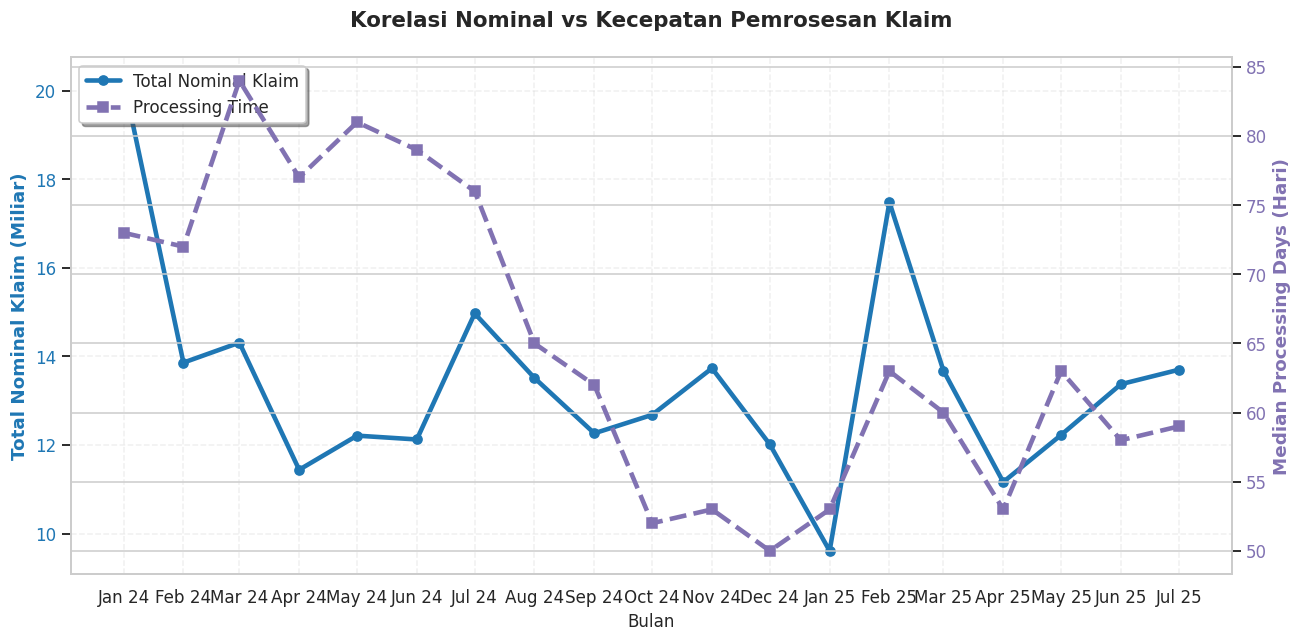

In [44]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Pastikan kolom Bulan bertipe datetime
nominal_trend['Bulan'] = pd.to_datetime(nominal_trend['Bulan'])
proc_trend['Bulan'] = pd.to_datetime(proc_trend['Bulan'])

# 1. Inisialisasi Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Plot 1: Total Nominal Klaim (Sumbu Y Kiri) ---
color_nominal = '#1f77b4' 
ax1.set_xlabel('Bulan', fontsize=11)
ax1.set_ylabel('Total Nominal Klaim (Miliar)', color=color_nominal, fontsize=12, fontweight='bold')
line1 = ax1.plot(nominal_trend['Bulan'], nominal_trend['Total']/1e9, 
                 marker='o', color=color_nominal, linewidth=3, label='Total Nominal Klaim')
ax1.tick_params(axis='y', labelcolor=color_nominal)
ax1.grid(True, linestyle='--', alpha=0.3)

# --- Plot 2: Processing Time (Sumbu Y Kanan) ---
ax2 = ax1.twinx() 
color_proc = '#8172B2' 
ax2.set_ylabel('Median Processing Days (Hari)', color=color_proc, fontsize=12, fontweight='bold')
line2 = ax2.plot(proc_trend['Bulan'], proc_trend['Processing_Days'], 
                 marker='s', color=color_proc, linewidth=3, linestyle='--', label='Processing Time')
ax2.tick_params(axis='y', labelcolor=color_proc)

# --- Formatting Sumbu X (Solusi Anti-Jir) ---
# Format: 'Jan 24', 'Feb 24', dst.
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
# Memastikan tiap bulan muncul labelnya
ax1.xaxis.set_major_locator(mdates.MonthLocator())

# 2. Pengaturan Judul dan Legenda
plt.title('Korelasi Nominal vs Kecepatan Pemrosesan Klaim', fontsize=14, fontweight='bold', pad=20)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True, shadow=True)

# Mempercantik tampilan label tanggal agar tidak tabrakan
fig.autofmt_xdate(rotation=0, ha='center') 

plt.tight_layout()
plt.show()


---
## Phase 5: Analisis Diagnosis (ICD)

### 5.1 Top 10 ICD per Lokasi RS

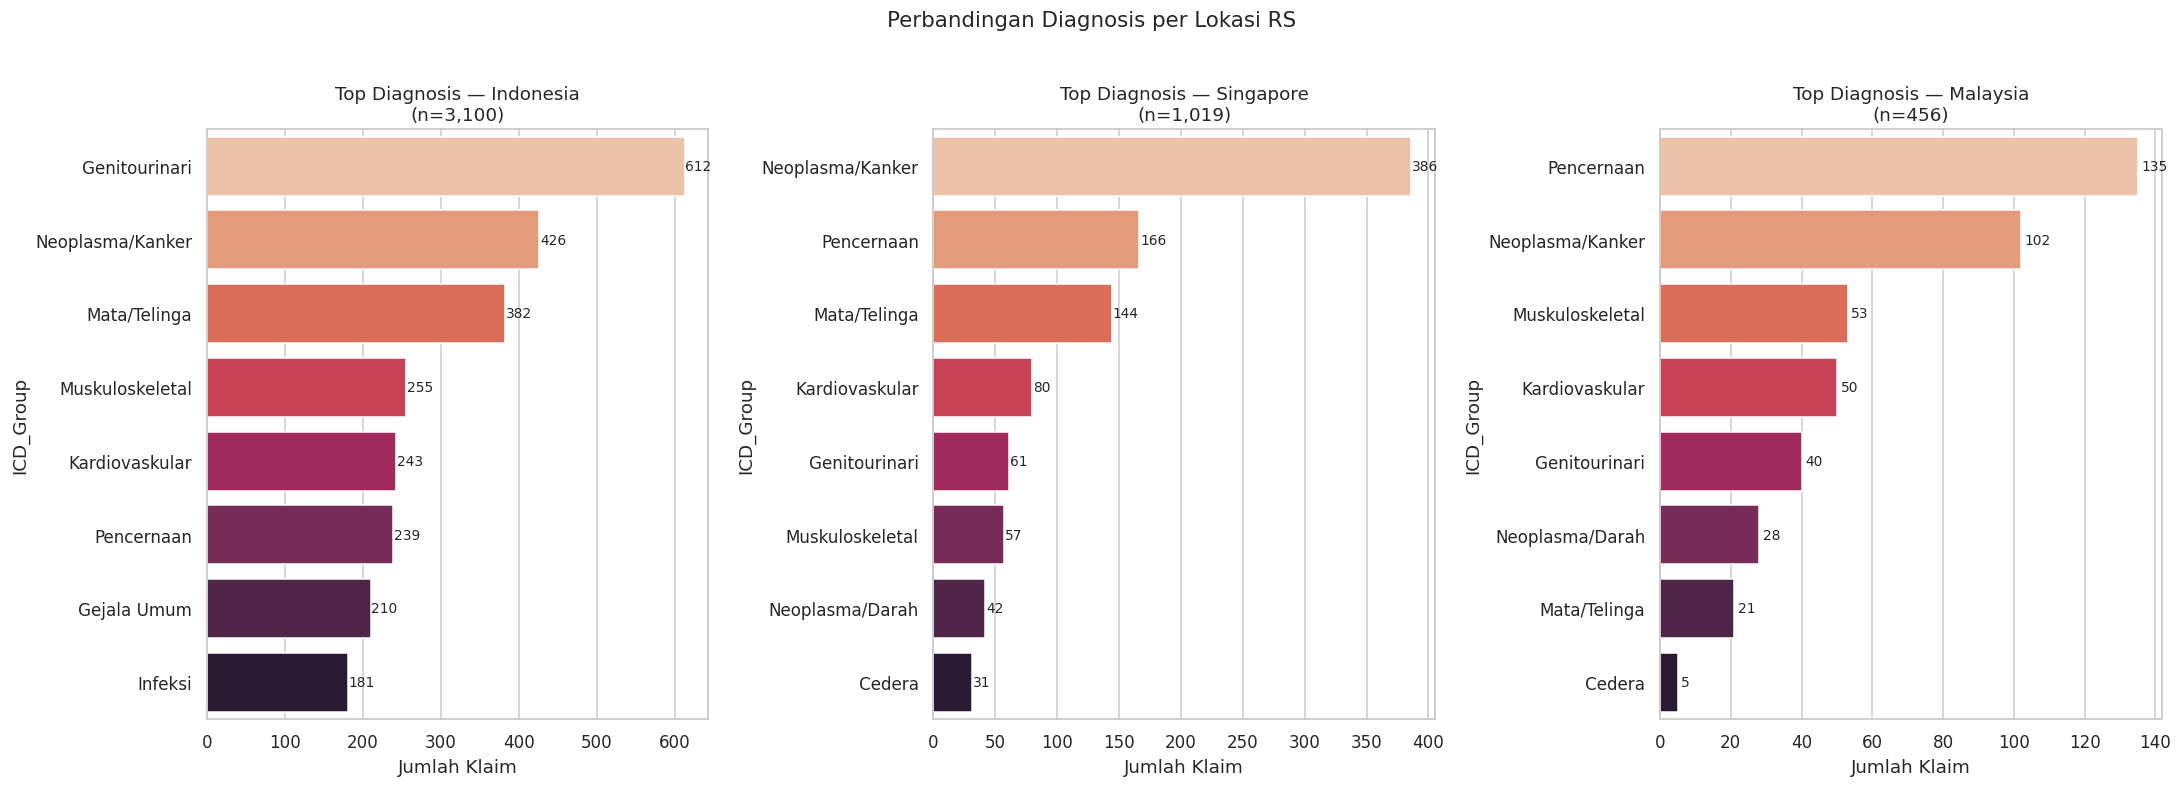

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, lokasi in zip(axes, ['Indonesia', 'Singapore', 'Malaysia']):
    data = df[df['Lokasi RS'] == lokasi]
    top_icd = data['ICD_Group'].value_counts().head(8)
    sns.barplot(y=top_icd.index, x=top_icd.values, ax=ax, palette='rocket_r')
    ax.set_title(f'Top Diagnosis — {lokasi}\n(n={len(data):,})')
    ax.set_xlabel('Jumlah Klaim')
    for bar, val in zip(ax.patches, top_icd.values):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{val}', va='center', fontsize=9)

plt.suptitle('Perbandingan Diagnosis per Lokasi RS', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Top ICD per Plan Code

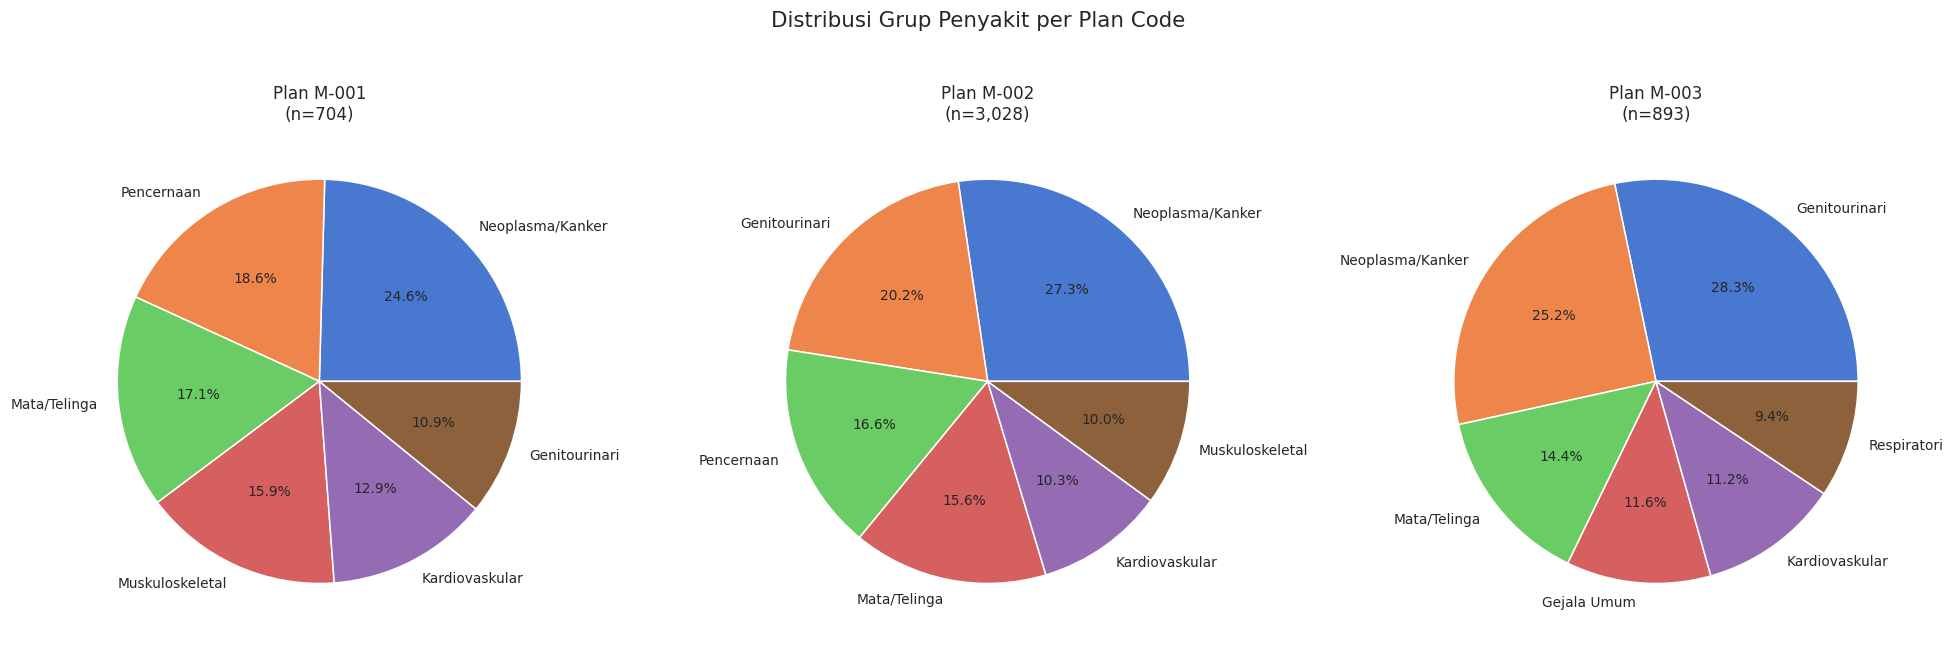

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, plan in zip(axes, ['M-001', 'M-002', 'M-003']):
    data = df[df['Plan Code'] == plan]
    top = data['ICD_Group'].value_counts().head(6)
    ax.pie(top, labels=top.index, autopct='%1.1f%%', textprops={'fontsize': 9})
    ax.set_title(f'Plan {plan}\n(n={len(data):,})', fontsize=11)

plt.suptitle('Distribusi Grup Penyakit per Plan Code', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5.3 ICD Group: Distribusi Keseluruhan & Cost Driver

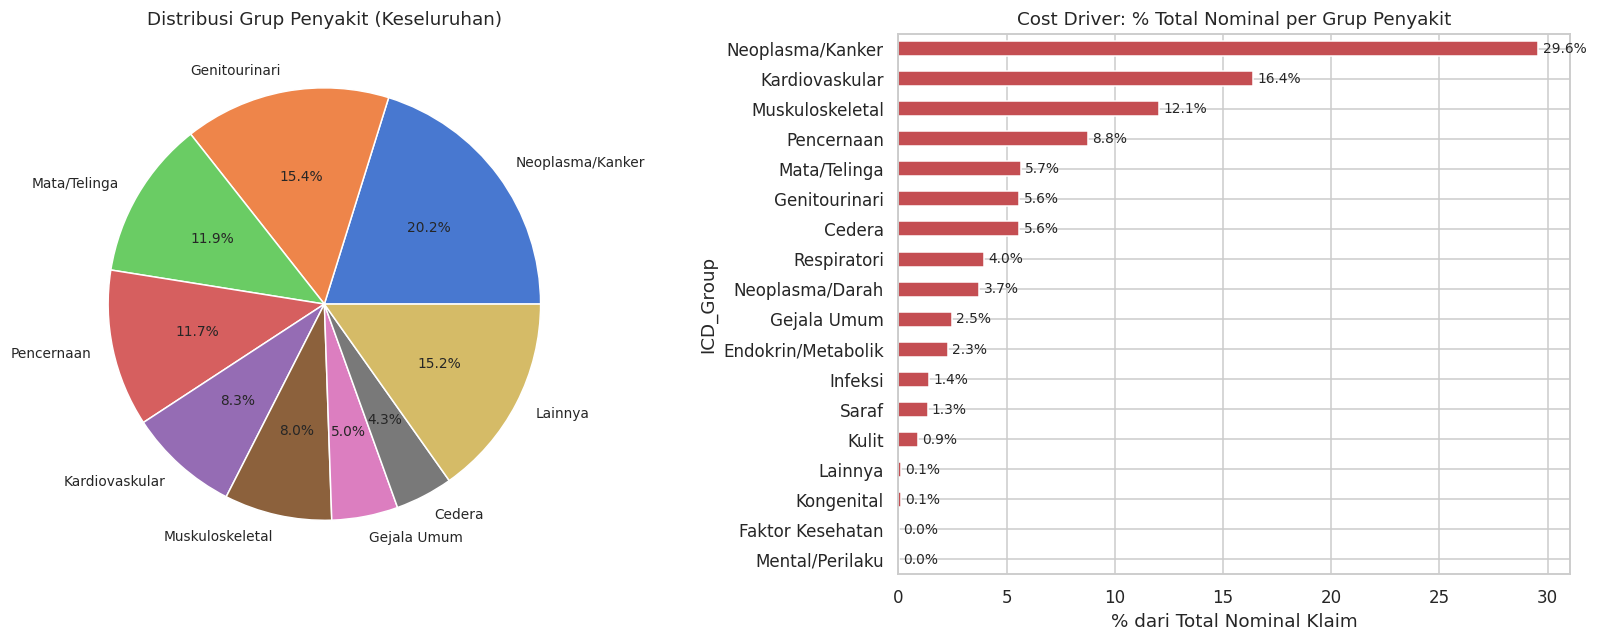

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart overall
icd_overall = df['ICD_Group'].value_counts()
top_n = 8
other = icd_overall[top_n:].sum()
icd_pie = pd.concat([icd_overall[:top_n], pd.Series({'Lainnya': other})])
axes[0].pie(icd_pie, labels=icd_pie.index, autopct='%1.1f%%', textprops={'fontsize': 9})
axes[0].set_title('Distribusi Grup Penyakit (Keseluruhan)')

# Cost driver: total nominal per ICD group as % of total
cost_driver = df.groupby('ICD_Group')['Nominal Klaim Yang Disetujui'].sum().sort_values(ascending=True)
cost_pct = (cost_driver / cost_driver.sum() * 100)
cost_pct.plot(kind='barh', ax=axes[1], color='#C44E52')
axes[1].set_title('Cost Driver: % Total Nominal per Grup Penyakit')
axes[1].set_xlabel('% dari Total Nominal Klaim')
for bar, val in zip(axes[1].patches, cost_pct.values):
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## Phase 6: Analisis Anomali & Outlier

### 6.1 Deteksi Outlier Nominal Klaim (IQR Method)

In [48]:
Q1 = df['Nominal Klaim Yang Disetujui'].quantile(0.25)
Q3 = df['Nominal Klaim Yang Disetujui'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Nominal Klaim Yang Disetujui'] < lower) | (df['Nominal Klaim Yang Disetujui'] > upper)]

print(f'IQR Method:')
print(f'  Q1     : Rp {Q1:,.0f}')
print(f'  Q3     : Rp {Q3:,.0f}')
print(f'  IQR    : Rp {IQR:,.0f}')
print(f'  Lower  : Rp {lower:,.0f}')
print(f'  Upper  : Rp {upper:,.0f}')
print(f'\n  Jumlah outlier: {len(outliers):,} ({len(outliers)/len(df)*100:.1f}%)')
print(f'  Total nominal outlier: Rp {outliers["Nominal Klaim Yang Disetujui"].sum()/1e9:.1f} Miliar')
print(f'  vs Total keseluruhan : Rp {df["Nominal Klaim Yang Disetujui"].sum()/1e9:.1f} Miliar')
print(f'  => Outlier = {outliers["Nominal Klaim Yang Disetujui"].sum()/df["Nominal Klaim Yang Disetujui"].sum()*100:.1f}% dari total nominal')

# Breakdown outlier per ICD Group
print(f'\nOutlier per Grup Penyakit:')
print(outliers['ICD_Group'].value_counts().to_string())

IQR Method:
  Q1     : Rp 2,275,384
  Q3     : Rp 51,115,437
  IQR    : Rp 48,840,053
  Lower  : Rp -70,984,696
  Upper  : Rp 124,375,517

  Jumlah outlier: 507 (11.0%)
  Total nominal outlier: Rp 160.8 Miliar
  vs Total keseluruhan : Rp 254.6 Miliar
  => Outlier = 63.2% dari total nominal

Outlier per Grup Penyakit:
ICD_Group
Neoplasma/Kanker      162
Kardiovaskular         96
Muskuloskeletal        78
Cedera                 34
Pencernaan             33
Mata/Telinga           24
Genitourinari          23
Neoplasma/Darah        18
Respiratori            15
Endokrin/Metabolik      8
Saraf                   6
Gejala Umum             5
Kulit                   3
Kongenital              1
Infeksi                 1


### 6.2 Anomali: Inpatient dengan LOS = 0 & Klaim Duplikat

In [49]:
from IPython.display import display

# Inpatient with LOS = 0
ip_los0 = df[(df['Inpatient/Outpatient'] == 'IP') & (df['LOS'] == 0)]
print(f'=== Inpatient dengan LOS = 0 hari: {len(ip_los0)} record ===')
if len(ip_los0) > 0:
    display(ip_los0[['Claim ID', 'Nomor Polis', 'ICD_Group', 'Nominal Klaim Yang Disetujui',
                      'Lokasi RS']].head(20).reset_index(drop=True))

# Duplicate check: same polis, same date, same nominal
dup_cols = ['Nomor Polis', 'Tanggal Pasien Masuk RS', 'Nominal Klaim Yang Disetujui']
dupes = df[df.duplicated(subset=dup_cols, keep=False)].sort_values(dup_cols)
print(f'\n=== Potential duplicates (same polis, date, nominal): {len(dupes)} record ===')
if len(dupes) > 0:
    display(dupes[['Claim ID', 'Nomor Polis', 'Tanggal Pasien Masuk RS',
                   'Nominal Klaim Yang Disetujui', 'ICD Diagnosis',
                   'Lokasi RS']].head(20).reset_index(drop=True))

=== Inpatient dengan LOS = 0 hari: 762 record ===


,Claim ID,Nomor Polis,ICD_Group,Nominal Klaim Yang Disetujui,Lokasi RS
0,C-0018-M,POL-3980,Kardiovaskular,1842000.0,Singapore
1,C-0020-M,POL-3980,Kardiovaskular,658000.0,Indonesia
2,C-0022-M,POL-1756,Respiratori,14916584.0,Indonesia
3,C-0040-M,POL-0071,Mata/Telinga,34344000.0,Indonesia
4,C-0041-M,POL-0071,Mata/Telinga,288200.0,Indonesia
5,C-0042-M,POL-0071,Mata/Telinga,2211800.0,Indonesia
6,C-0095-M,POL-1697,Kulit,1021663.0,Indonesia
7,C-0096-M,POL-1697,Kulit,1478337.0,Indonesia
8,C-0108-M,POL-0863,Respiratori,1950580.0,Singapore
9,C-0109-M,POL-0863,Respiratori,104747388.0,Singapore



=== Potential duplicates (same polis, date, nominal): 16 record ===


,Claim ID,Nomor Polis,Tanggal Pasien Masuk RS,Nominal Klaim Yang Disetujui,ICD Diagnosis,Lokasi RS
0,C-1756-M,POL-0158,2024-05-28,17145200.0,T18.4,Malaysia
1,C-1758-M,POL-0158,2024-05-28,17145200.0,T18.4,Malaysia
2,C-1762-M,POL-0324,2024-04-02,499000.0,N10,Indonesia
3,C-1764-M,POL-0324,2024-04-02,499000.0,N10,Indonesia
4,C-1761-M,POL-0324,2024-04-02,610000.0,N10,Indonesia
5,C-1767-M,POL-0324,2024-04-02,610000.0,N10,Indonesia
6,C-2690-M,POL-0935,2024-07-22,2500000.0,I84.1,Singapore
7,C-2692-M,POL-0935,2024-07-22,2500000.0,K62.1,Singapore
8,C-0083-M,POL-2125,2024-06-21,0.0,H25.9,Indonesia
9,C-0085-M,POL-2125,2024-06-21,0.0,H25.9,Indonesia


---
## Phase 7: Summary & Key Insights

### Dashboard Ringkasan

In [50]:
print('=' * 70)
print('           DASHBOARD RINGKASAN — DATA KLAIM ASURANSI')
print('=' * 70)
print(f'''
  Periode Data         : {df["Tanggal Pasien Masuk RS"].min().strftime("%b %Y")} — {df["Tanggal Pasien Masuk RS"].max().strftime("%b %Y")}
  Total Klaim           : {len(df):,} transaksi
  Total Polis Aktif      : {df["Nomor Polis"].nunique():,} dari {len(dp):,} polis ({df["Nomor Polis"].nunique()/len(dp)*100:.1f}%)
  Total Nominal Klaim    : Rp {df["Nominal Klaim Yang Disetujui"].sum()/1e9:.1f} Miliar
  Rata-rata per Klaim    : Rp {df["Nominal Klaim Yang Disetujui"].mean()/1e6:.1f} Juta
  Median per Klaim       : Rp {df["Nominal Klaim Yang Disetujui"].median()/1e6:.1f} Juta

  Reimburse vs Cashless  : {(df["Reimburse/Cashless"]=="R").mean()*100:.0f}% vs {(df["Reimburse/Cashless"]=="C").mean()*100:.0f}%
  Indonesia vs LN        : {(df["Lokasi_Group"]=="Indonesia").mean()*100:.0f}% vs {(df["Lokasi_Group"]=="Luar Negeri").mean()*100:.0f}%
  Avg Processing Time    : {df["Processing_Days"].dropna().median():.0f} hari (median)

  Top Diagnosis          : {df["ICD_Group"].value_counts().index[0]} ({df["ICD_Group"].value_counts().values[0]:,} klaim)
  Top Cost Driver        : {df.groupby("ICD_Group")["Nominal Klaim Yang Disetujui"].sum().idxmax()}
  Top Repeat Claimer     : {klaim_per_polis.index[0]} ({klaim_per_polis.values[0]} klaim)
''')
print('=' * 70)

           DASHBOARD RINGKASAN — DATA KLAIM ASURANSI

  Periode Data         : Jan 2024 — Jul 2025
  Total Klaim           : 4,625 transaksi
  Total Polis Aktif      : 1,210 dari 4,096 polis (29.5%)
  Total Nominal Klaim    : Rp 254.6 Miliar
  Rata-rata per Klaim    : Rp 55.0 Juta
  Median per Klaim       : Rp 14.5 Juta

  Reimburse vs Cashless  : 59% vs 41%
  Indonesia vs LN        : 67% vs 33%
  Avg Processing Time    : 61 hari (median)

  Top Diagnosis          : Neoplasma/Kanker (934 klaim)
  Top Cost Driver        : Neoplasma/Kanker
  Top Repeat Claimer     : POL-2078 (222 klaim)



### Kesimpulan & Insight Utama

**1. Profil Klaim:**
- Data mencakup ~19 bulan klaim. Dari 4,096 polis, hanya ~29.5% yang pernah klaim
- Distribusi nominal sangat right-skewed — mayoritas klaim kecil, tapi outlier sangat besar
- Korelasi biaya RS vs nominal klaim sangat tinggi (r ≈ 0.99)

**2. Anomali & Data Quality:**
- 13 klaim dengan nominal Rp 0 (perlu investigasi)
- 36 klaim dimana nominal disetujui > biaya RS (over-coverage)
- Beberapa repeat claimers ekstrem (222 dan 167 klaim) — perlu review apakah fraud atau memang chronic patient
- 2 record dihapus karena terlalu banyak missing values

**3. Pola Demografis & Geografi:**
- Gender cenderung seimbang dalam jumlah klaim
- Mayoritas berobat di Indonesia (67%), namun biaya di luar negeri jauh lebih tinggi
- Singapore dan Malaysia jadi tujuan utama berobat ke luar negeri

**4. Cost Drivers:**
- Kanker (Neoplasma) kemungkinan menjadi cost driver terbesar
- Berobat ke Singapore rata-rata paling mahal
- Inpatient secara natural lebih mahal daripada Outpatient

**5. Temporal:**
- Perlu dilihat apakah ada tren peningkatan/penurunan klaim
- Processing time perlu dimonitor untuk service level

**Rekomendasi Lanjutan:**
- Deep-dive fraud analysis pada repeat claimers ekstrem
- Cost containment analysis untuk klaim luar negeri
- Predictive modeling untuk estimasi klaim masa depan